In [29]:
import seaborn as sns
# sns.setcolor_palette("mako", as_cmap=True)
sns.set_palette("mako")

In [1]:
from pathlib import Path
import dask.array as da
import pandas as pd
import anndata as ad
import napari
import numpy as np
from tqdm.auto import tqdm
import json

expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']


def timed_compute(volume):
    """
    Compute a lazy Dask array frame-by-frame with progress reporting.

    This function iterates over the leading axis of a Dask array (e.g. time),
    calls `.compute()` on each slice, and stacks the results into a single
    NumPy array. A tqdm progress bar is displayed to indicate progress.

    Parameters
    ----------
    volume : dask.array.Array
        A Dask array with at least one dimension (e.g. shape (T, ...)).
        The function will iterate over the first axis (axis=0).

    Returns
    -------
    numpy.ndarray
        A NumPy array with the same shape as `volume`, but fully realized
        in memory. The dtype is preserved from the Dask array.

    Notes
    -----
    - Each frame is computed independently, which can be helpful for
      monitoring performance and memory use on large arrays.
    - The returned array may be very large if `volume` is large.
      Ensure sufficient memory is available.
    """
    return np.stack([frame.compute() for frame in tqdm(volume)], axis=0)


In [2]:
# root_dir = Path('/mnt/OPERA3/Nathan/Z_stack_tests/zarr')
root_dir = Path('/Volumes/OPERA3/Nathan/Z_stack_tests/zarr')
rc_stem = "(3,3)"
store = root_dir / f"{rc_stem}.zarr"

# --- load images and segmentation ---
images = da.from_zarr(str(store / "images" / "0"))   # (T,C,Z,Y,X)
masks  = da.from_zarr(str(store / "labels" / "masks"))  # (T,Z,Y,X)

# --- load tracks (CSV preferred, fallback to AnnData) ---
# tracks_csv = root_dir / f"{rc_stem}_tracks.csv"
# if tracks_csv.exists():
#     tracks = pd.read_csv(tracks_csv)
# else:
adata = ad.read_zarr(str(store / "tables" / "quantified_tracks"))
tracks = adata.obs.reset_index(drop=True)

print("images:", images.shape)
print("masks:", masks.shape)
print("tracks:", tracks.shape)


images: (97, 2, 25, 7992, 7992)
masks: (97, 25, 7992, 7992)
tracks: (1859520, 10)


In [3]:
tracks

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col
0,0,1,0,866,6511,18375,0,817,3,3
1,0,1,1,866,6511,18900,0,817,3,3
2,0,1,2,866,6511,18475,0,817,3,3
3,0,1,3,866,6511,17600,0,817,3,3
4,0,1,4,866,6511,18425,0,817,3,3
...,...,...,...,...,...,...,...,...,...,...
1859515,96,8594,15,4487,1550,14050,704,42,3,3
1859516,96,8594,16,4487,1550,12850,654,42,3,3
1859517,96,8594,17,4487,1550,11425,140,42,3,3
1859518,96,8594,18,4487,1550,9600,0,42,3,3


In [10]:
%%time
# full time axis
all_t = np.arange(tracks['t'].min(), tracks['t'].max() + 1, dtype=int)

# reindex each track-z group to break lines on missing timepoints
def expand_group(g):
    out = g.set_index('t').reindex(all_t)
    out['ID'] = g.name[0]
    out['z']  = g.name[1]
    return out.reset_index().rename(columns={'index': 't'})

tracks = (tracks
    .groupby(['ID', 'z'], group_keys=False)
    .apply(expand_group)
)

CPU times: user 15.1 s, sys: 198 ms, total: 15.3 s
Wall time: 15.3 s


<timed exec>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [11]:
napari_tracks = tracks[['ID', 't', 'z', 'y', 'x']].to_numpy(dtype=np.int64)
napari_tracks.shape

/Users/dayn/miniforge3/envs/godspeed/lib/python3.10/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr


(3037167, 5)

In [9]:
viewer = napari.Viewer(title = 'inspecting tracks and quantifications')
viewer.add_image(images, channel_axis=1)
viewer.add_labels(masks)
viewer.add_tracks(napari_tracks)

<Tracks layer 'napari_tracks' at 0x76eb9c2b0130>

In [12]:
napari_tracks[:, 1].shape

(1859520,)

In [150]:
# features = {
#     'time': tracks['t'].values,
#     'mtb_area_px': tracks['mtb_area_px'].values
# }

features = {
    col: tracks[col].values
    for col in tracks.columns
}

In [21]:
viewer.layers['napari_tracks'].features = features

## Working with a subset of data

In [116]:
shapes = viewer.layers['Shapes'].data[0]

In [117]:
shapes

array([[  48.        ,   12.        , 1150.17435385, 3270.44807186],
       [  48.        ,   12.        , 1150.17435385, 5046.11438262],
       [  48.        ,   12.        , 3059.55047718, 5046.11438262],
       [  48.        ,   12.        , 3059.55047718, 3270.44807186]])

In [118]:
vertices = shapes[:,2:]
y0, y1 = int(np.floor(vertices[:, 0].min())), int(np.ceil(vertices[:, 0].max()))
x0, x1 = int(np.floor(vertices[:, 1].min())), int(np.ceil(vertices[:, 1].max()))
x0, x1, y0, y1

(3270, 5047, 1150, 3060)

In [7]:
x0, x1, y0, y1 = 3270, 5047, 1150, 3060

In [8]:
images_roi = images[:, :, :, y0:y1, x0:x1]
masks_roi  = masks[:, :, y0:y1, x0:x1]


In [199]:
roi_tracks = tracks[(tracks['y'] >= y0) & (tracks['y'] < y1) &
                    (tracks['x'] >= x0) & (tracks['x'] < x1)]
roi_tracks['y'] = roi_tracks['y'] - y0
roi_tracks['x'] = roi_tracks['x'] - x0

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_72879/493691589.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['y'] = roi_tracks['y'] - y0
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_72879/493691589.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['x'] = roi_tracks['x'] - x0


In [66]:

images_roi = np.stack([frame.compute() for frame in tqdm(images_roi)], axis=0)

  0%|          | 0/97 [00:00<?, ?it/s]

In [71]:
viewer_2 = napari.Viewer(title = 'testing on subset')

In [90]:
scale = [1.0, 0.14949, 0.14949]

In [70]:
images_roi.shape

(97, 2, 25, 1910, 1777)

In [92]:
viewer_2.add_image(images_roi, channel_axis = 1, scale = scale)

[<Image layer 'Image' at 0x76eb9687f250>, <Image layer 'Image [1]' at 0x76eb9687d4b0>]

In [93]:
masks_rio = timed_compute(masks_roi)

  0%|          | 0/97 [00:00<?, ?it/s]

In [95]:
viewer_2.add_labels(masks_roi, scale = scale)

<Labels layer 'masks_roi' at 0x76eb7bc1e3b0>

In [121]:
napari_tracks =  roi_tracks[roi_tracks["z"] == 12][['ID', 't', 'z', 'y', 'x']].to_numpy(dtype=np.int64)
napari_tracks.shape

(3913, 5)

In [122]:
# features = {
#     'time': tracks['t'].values,
#     'mtb_area_px': tracks['mtb_area_px'].values
# }

features = {
    col: roi_tracks[col].values
    for col in roi_tracks.columns
}

In [123]:
napari_tracks

array([[ 237,    0,   12, 1411, 1358],
       [ 313,    0,   12,  175,  253],
       [ 397,    0,   12, 1203,  814],
       ...,
       [6658,   96,   12, 1716,   89],
       [6664,   96,   12, 1249, 1355],
       [7546,   96,   12, 1841,  610]])

In [113]:
viewer_2.add_tracks(napari_tracks, scale = scale,)# features = features)

<Tracks layer 'napari_tracks [1]' at 0x76eb96b50580>

In [125]:
scale

[1.0, 0.14949, 0.14949]

In [126]:
norm_scale = [1/0.14949, 1, 1]
for layer in viewer_2.layers:
    layer.scale = norm_scale

In [153]:
roi_tracks[roi_tracks['ID'] == 2280]

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col
0,0,2280,0,1739.0,1302.0,23125.0,0.0,868.0,3.0,3.0
48,48,2280,0,1735.0,1353.0,16575.0,0.0,572.0,3.0,3.0
52,52,2280,0,1717.0,1288.0,19775.0,0.0,171.0,3.0,3.0
54,54,2280,0,1722.0,1312.0,15650.0,0.0,222.0,3.0,3.0
59,59,2280,0,1722.0,1296.0,23275.0,0.0,223.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...
92,92,2280,24,1719.0,1268.0,16250.0,0.0,537.0,3.0,3.0
93,93,2280,24,1719.0,1279.0,15825.0,0.0,444.0,3.0,3.0
94,94,2280,24,1725.0,1276.0,17100.0,0.0,1060.0,3.0,3.0
95,95,2280,24,1727.0,1282.0,15750.0,155.0,236.0,3.0,3.0


In [128]:
import seaborn as sns

In [158]:
tracks[tracks['ID'] == track_ID]

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col
0,0,615,0,1853.0,3728.0,21750.0,0.0,529.0,3.0,3.0
1,1,615,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,615,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,615,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,615,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
92,92,615,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,93,615,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,94,615,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,95,615,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN


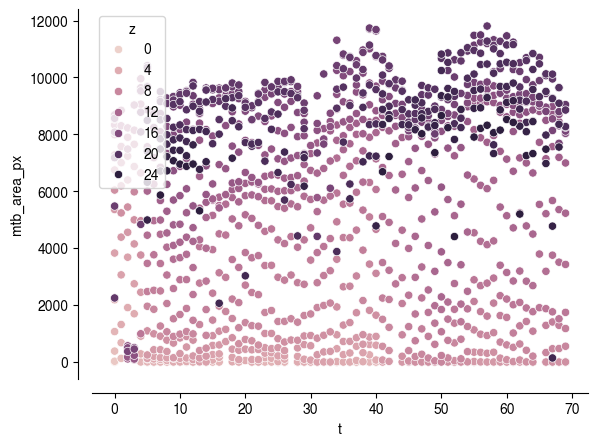

In [169]:
track_ID = 615
sc_df = roi_tracks[roi_tracks['ID'] == track_ID]
sns.scatterplot(data = sc_df, x = 't', y = 'mtb_area_px', hue='z', color='magenta')
sns.despine(offset=10)

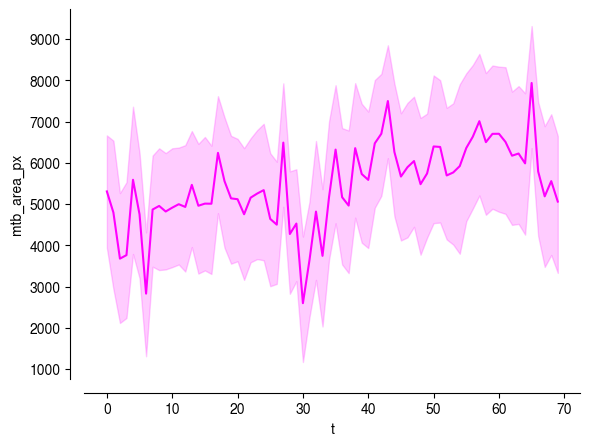

In [166]:
track_ID = 615
sc_df = roi_tracks[roi_tracks['ID'] == track_ID]
sns.lineplot(data = sc_df, x = 't', y = 'mtb_area_px', color='magenta',)
sns.despine(offset=10)

# Process Mtb signals

In [5]:
import importlib
import macrohet.growth_model

importlib.reload(macrohet.growth_model)

from macrohet.growth_model import (
    collate_tracks_to_df,
    compute_doubling_metrics,
    fit_lowess,
    process_mtb_area,
)


ModuleNotFoundError: No module named 'macrohet'

In [10]:
"""growth_model.py

Tools for processing single-cell intracellular Mtb growth data,
including smoothing, fitting, and growth/doubling metrics.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

def smooth_and_fix(area_series, window=10, spike_threshold=2.0):
    area_series = area_series.reset_index(drop=True)
    rolling_mean = area_series.rolling(window=window, min_periods=1).mean()
    cleaned = area_series.copy()
    for i in range(1, len(cleaned) - 1):
        if cleaned.iloc[i] > spike_threshold * rolling_mean.iloc[i]:
            cleaned.iloc[i] = np.nan
        elif (
            cleaned.iloc[i] == 0
            and cleaned.iloc[i - 1] > 0
            and cleaned.iloc[i + 1] > 0
        ):
            cleaned.iloc[i] = np.nan
    return cleaned.interpolate()


def process_mtb_area(df, window=10, spike_threshold=2.0):
    cleaned_series = df.groupby("ID")["Mtb Area (\u00b5m)"].transform(
        lambda x: smooth_and_fix(x, window, spike_threshold)
    )
    df = df.copy()
    df["Mtb Area Processed (\u00b5m)"] = cleaned_series.reset_index(
        level=0, drop=True
    )
    return df


def fit_lowess(df, frac=0.25, default_window=10, control_window=5):
    df = df.copy()
    df["Time Model (hours)"] = np.nan
    df["Mtb Area Model (µm)"] = np.nan
    df["r2"] = np.nan

    for ID in tqdm(df["ID"].unique(), desc="Fitting LOWESS"):
        sc_df = df[df["ID"] == ID]

        if isinstance(ID, str) and "PS0000" in ID:
            window = control_window
        else:
            window = default_window

        time = sc_df["Time (hours)"].values
        pop = sc_df["Mtb Area Processed (µm)"].values
        if len(time) < 2:
            continue

        model = sm.nonparametric.lowess(endog=pop, exog=time, frac=frac)
        time_model = model[:, 0] - (window / 2) + 0.5
        population_model = np.clip(model[:, 1], 0, None)

        if len(time_model) < len(sc_df):
            pad = len(sc_df) - len(time_model)
            time_model = np.concatenate(
                [np.full(pad // 2, np.nan), time_model, np.full(pad - pad // 2, np.nan)]
            )
            population_model = np.concatenate(
                [np.full(pad // 2, np.nan), population_model, np.full(pad - pad // 2, np.nan)]
            )

        df.loc[df["ID"] == ID, "Time Model (hours)"] = time_model
        df.loc[df["ID"] == ID, "Mtb Area Model (µm)"] = population_model
        df.loc[df["ID"] == ID, "r2"] = r2_score(
            sc_df["Mtb Area Processed (µm)"], model[:, 1]
        )

    return df



def compute_doubling_metrics(df, min_area=1.92, r2_threshold=0.7):
    df = df.copy()
    df["Doubling Amounts"] = None
    df["Doubling Times"] = None
    for ID in tqdm(df["ID"].unique(), desc="Doubling Metrics"):
        sc_df = df[df["ID"] == ID].dropna(
            subset=[
                "Time Model (hours)",
                "Mtb Area Model (\u00b5m)",
                "Mtb Area Processed (\u00b5m)",
            ]
        )
        if sc_df.empty:
            continue

        r2 = sc_df["r2"].iloc[0]
        if r2 < r2_threshold:
            continue

        min_val = max(sc_df["Mtb Area Model (\u00b5m)"].min(), min_area)
        max_val = sc_df["Mtb Area Model (\u00b5m)"].max()
        if max_val <= min_val:
            continue

        N_series = []
        N_i = min_val
        while N_i <= max_val:
            N_series.append(N_i)
            N_i *= 2

        if len(N_series) < 2:
            continue

        times = sc_df["Time Model (hours)"]
        model_vals = sc_df["Mtb Area Model (\u00b5m)"]
        doubling_idx = [np.abs(model_vals - val).idxmin() for val in N_series]
        doubling_times = (
            times.loc[doubling_idx].diff().dropna().values.tolist()
        )

        df.loc[df["ID"] == ID, "Doubling Amounts"] = [N_series] * len(sc_df)
        df.loc[df["ID"] == ID, "Doubling Times"] = [doubling_times] * len(
            sc_df
        )

    return df


### Add scale to df

In [200]:
px_size_um = 0.14949
px_area_um2 = px_size_um ** 2
frame_rate = 0.5
# add new column in µm²
roi_tracks['Mtb Area (µm)'] = roi_tracks['mtb_area_px'] * px_area_um2
roi_tracks['Time (hours)'] = roi_tracks['t'] * frame_rate

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_72879/469547302.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['Mtb Area (µm)'] = roi_tracks['mtb_area_px'] * px_area_um2
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_72879/469547302.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['Time (hours)'] = roi_tracks['t'] * frame_rate


In [201]:
df = roi_tracks

### Add Z discernible IDs and store OG ID

In [203]:
df = df.copy()  # avoid SettingWithCopyWarning

# element-wise concatenation
df['ID_og'] = df['ID']
df["ID"] = df["ID"].astype(str) + "_" + df["z"].astype(str)

print(df[["ID", "z"]].head())


        ID  z
858  237_1  1
859  237_2  2
860  237_3  3
861  237_4  4
862  237_5  5


### Process Mtb signal 

In [204]:
df = df.copy()
df["Mtb Area Processed (µm)"] = np.nan  # new column

for ID in tqdm(df['ID'].unique(), total=df['ID'].nunique()):
    mask = df['ID'] == ID
    sc_df = df.loc[mask]

    if len(sc_df) < 10:
        continue

    s  = sc_df['Mtb Area (µm)']
    rm = s.rolling(window=10, min_periods=1).mean()

    spike = s > 2.0 * rm
    iso0  = (s == 0) & (s.shift(1) > 0) & (s.shift(-1) > 0)

    cleaned = (s.mask(spike | iso0)
                 .interpolate()
                 .bfill()
                 .ffill())

    # assign cleaned back into df for this ID
    df.loc[mask, "Mtb Area Processed (µm)"] = cleaned.values


  0%|          | 0/1241 [00:00<?, ?it/s]

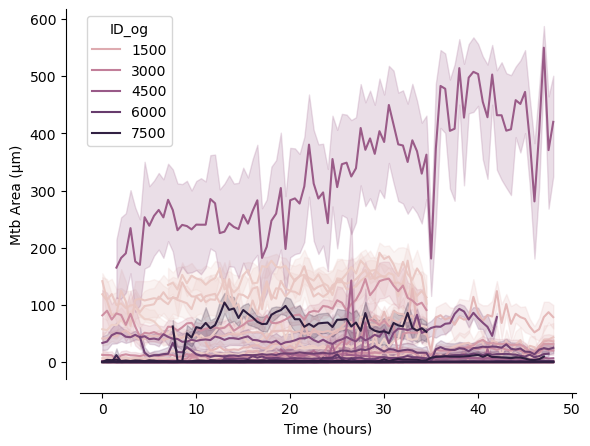

In [18]:
sns.lineplot(data=df, x='Time (hours)', y = 'Mtb Area (µm)', hue='ID_og')
sns.despine(offset=10)


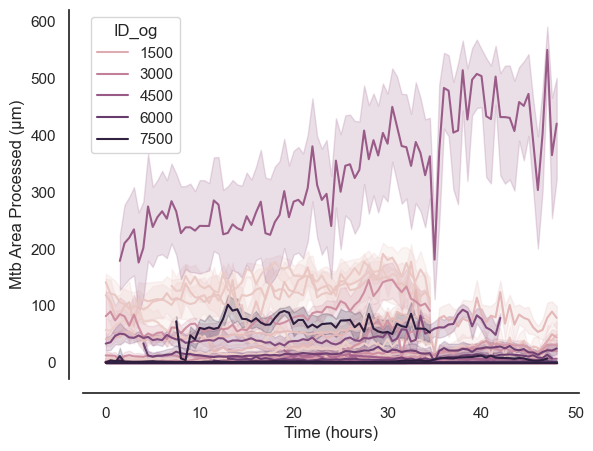

In [19]:
# ---- plot
sns.set_theme(style="white")
ax = sns.lineplot(
    data=df.dropna(subset=["Time (hours)", "Mtb Area Processed (µm)"]), 
    x="Time (hours)", y="Mtb Area Processed (µm)",
    hue="ID_og",
)
sns.despine(offset=10)


### Fit LOWESS growth models to Mtb growth

In [205]:
frac = 0.25
default_window = 10
control_window = 5
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score

df = df.copy()
df["Time Model (hours)"] = np.nan
df["Mtb Area Model (µm)"] = np.nan
df["r2"] = np.nan

for ID in tqdm(df["ID"].unique(), desc="Fitting LOWESS"):
    sc_df = df[df["ID"] == ID]
    window = control_window if (isinstance(ID, str) and "PS0000" in ID) else default_window

    # 1) sort by time so LOWESS x is monotonic and aligns on write-back
    sc = sc_df.sort_values("Time (hours)").copy()
    time = sc["Time (hours)"].to_numpy(dtype=float)
    pop  = sc["Mtb Area Processed (µm)"].to_numpy(dtype=float)

    if len(time) < 10:
        continue

    # 2) LOWESS returns (x_sorted, y_smoothed) at the same x positions
    model = sm.nonparametric.lowess(endog=pop, exog=time, frac=frac, return_sorted=True)
    time_model = model[:, 0]                      # <-- no shift
    population_model = np.clip(model[:, 1], 0, None)

    # 3) write back to the *sorted* rows so positions match
    df.loc[sc.index, "Time Model (hours)"] = time_model
    df.loc[sc.index, "Mtb Area Model (µm)"] = population_model

    # 4) r² on aligned arrays (same length, sorted)
    df.loc[sc.index, "r2"] = r2_score(pop, model[:, 1])

Fitting LOWESS:   0%|          | 0/1241 [00:00<?, ?it/s]

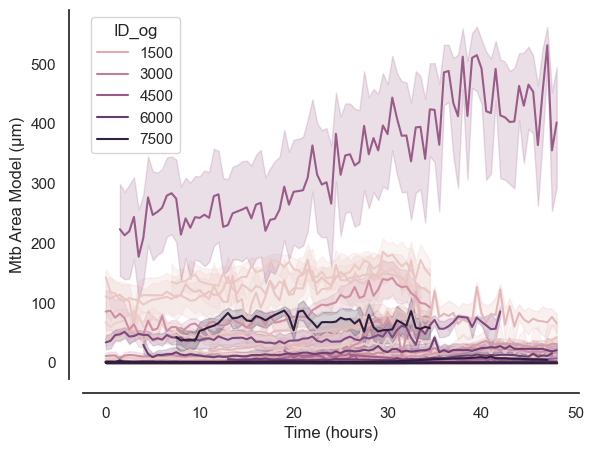

In [21]:
sns.lineplot(data=df.dropna(subset=["Time (hours)", "Mtb Area Model (µm)"]), 
            x='Time (hours)', y = 'Mtb Area Model (µm)', hue='ID_og')
sns.despine(offset=10)

In [25]:
df[df['Mtb Area Model (µm)'] == df['Mtb Area Model (µm)'].max()]

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),ID_og,Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2
1625738,83,4472_9,9,727,1101,30850,26375,1620,3,3,589.408985,41.5,4472,589.408985,37.0,579.027331,0.875436


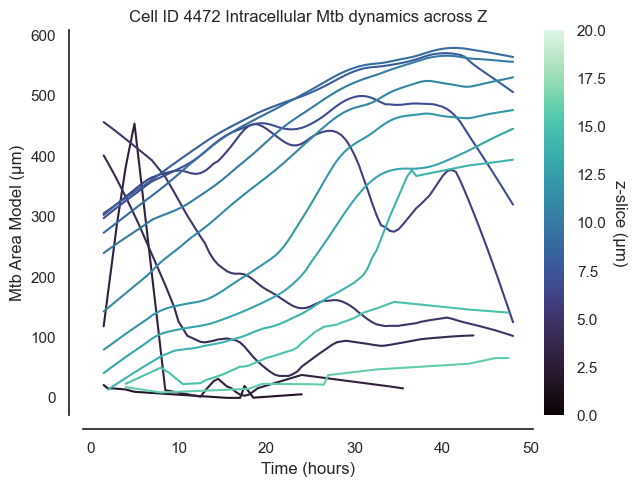

In [179]:

# Assume 'ID' encodes z slices as integers after the underscore
ID = 4472
df4472 = df[df["ID_og"] == ID].copy()
df4472["z"] = df4472["ID"].str.split("_").str[-1].astype(int)

# Set up figure
fig, ax = plt.subplots(figsize=(7,5))

# Use scatterplot or lineplot with continuous colormap
norm = plt.Normalize(df4472["z"].min(), df4472["z"].max())
cmap = sns.color_palette("mako", as_cmap=True)

sns.lineplot(
    data=df4472,
    x="Time (hours)", y="Mtb Area Model (µm)",
    hue="z", palette=cmap, hue_norm=norm,
    legend=False, ax=ax
)
# Style
sns.despine(offset=10)
# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = ax.figure.colorbar(sm, ax=ax, pad=0.02)

# Remove the box + ticks
cbar.outline.set_visible(False)   # removes the frame box
cbar.ax.tick_params(left=False, right=False, labelleft=False)  # no ticks/labels

# After creating the colorbar:
cbar.outline.set_visible(False)        # removes the border box
cbar.ax.tick_params(left=False, right=False, labelleft=False,)  # no ticks/labels at all

# Remove the colorbar spines (axes lines)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)
    
# Optional: keep only a label floating next to the strip
cbar.set_label("z-slice (µm)", rotation=270, labelpad=15)


ax.set_ylabel("Mtb Area Model (µm)")
ax.set_xlabel("Time (hours)")

plt.title(f'Cell ID {ID} Intracellular Mtb dynamics across Z')
plt.savefig(f'/Volumes/OPERA3/Nathan/Z_stack_tests/results/Cell ID {ID} across Z.pdf', dpi = 314, bbox_inches ='tight')

In [69]:
def maxproj_group3(df, length=6):
    """
    For each parent ID and timepoint, take max-projection
    over groups of `length` consecutive z-slices.
    """
    out = []

    # Loop over each parent ID separately
    for gid, g in df.groupby("ID_og"):
        # Pivot to (time x z) table
        grid = g.pivot_table(
            index="Time (hours)", 
            columns="z", 
            values="Mtb Area Model (µm)", 
            aggfunc="max"
        )
        grid = grid.sort_index(axis=1)

        z_vals = grid.columns.to_numpy()
        if len(z_vals) == 0:
            continue

        # slide over z with window size = length
        for i in range(len(z_vals) - length + 1):
            cols = z_vals[i:i+length]
            proj = grid[cols].max(axis=1)

            tmp = proj.reset_index()
            tmp["ID_og"] = gid
            tmp["proj_name"] = f"z{cols[0]}-{cols[-1]}"
            tmp["Mtb Area Model (µm)"] = proj.values

            out.append(tmp[["ID_og", "Time (hours)", "proj_name", "Mtb Area Model (µm)"]])

    if not out:
        return df.iloc[0:0].copy()

    return pd.concat(out, ignore_index=True)

In [65]:
df[df['ID_og']==4472]['z'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,  0, 14, 15, 16,
       17, 18, 19, 20], dtype=int32)

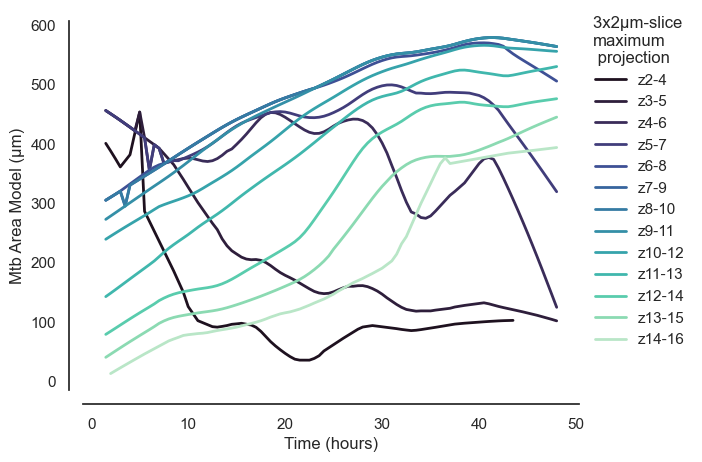

In [71]:
df4472_proj = maxproj_group3(df[df["ID_og"] == 4472], length=3)

sns.set_theme(style="white")
ax = sns.lineplot(
    data=df4472_proj.dropna(subset=["Mtb Area Model (µm)"]),
    x="Time (hours)", y="Mtb Area Model (µm)", hue="proj_name", linewidth=2, palette='mako'
)
sns.despine(offset=10)
ax.set_ylabel("Mtb Area Model (µm)")
ax.set_xlabel("Time (hours)")
ax.legend(title="3x2µm-slice \nmaximum\n projection", frameon=False,bbox_to_anchor=(1.0, 1.05))

In [207]:
def maxproj_stride2(df, length=3, min_points=1):
    """
    Build 3-slice max-projections separated by 2 µm: (z, z+2, z+4).
    Returns ['ID_og','Time (hours)','proj_name','Mtb Area Model (µm)'].
    """
    out = []
    for gid, g in df.groupby("ID_og"):
        grid = (g.pivot_table(index="Time (hours)", columns="z",
                              values="Mtb Area Model (µm)", aggfunc="max")
                  .sort_index(axis=1))
        if grid.empty:
            continue
        z_vals = sorted(grid.columns.astype(int))
        starts = [z for z in z_vals if all((z + k*2) in z_vals for k in range(length))]
        # max_max_proj = grid.max(axis=1, skipna=True)
        
        for z0 in starts:
            cols = [z0 + 2*k for k in range(length)]
            proj = grid[cols].max(axis=1, skipna=True)
            if proj.notna().sum() < min_points:
                continue
            tmp = proj.reset_index()
            tmp["ID_og"] = gid
            tmp["proj_name"] = f"z{cols[0]}-{cols[-1]}"
            tmp["Mtb Area Model (µm)"] = proj.values
            out.append(tmp[["ID_og","Time (hours)","proj_name","Mtb Area Model (µm)"]])
    return pd.concat(out, ignore_index=True) if out else df.iloc[0:0].copy()


In [226]:
out = []
length=3
min_points=1
for gid, g in df.groupby("ID_og"):
    if gid != 4472:
        continue
    else:
        print('this works')
    grid = (g.pivot_table(index="Time (hours)", columns="z",
                          values="Mtb Area Model (µm)", aggfunc="max")
              .sort_index(axis=1))
    if grid.empty:
        continue
    z_vals = sorted(grid.columns.astype(int))
    starts = [z for z in z_vals if all((z + k*2) in z_vals for k in range(length))]
    # max_max_proj = grid.max(axis=1, skipna=True)
    
    for z0 in starts:
        cols = [z0 + 2*k for k in range(length)]
        proj = grid[cols].max(axis=1, skipna=True)
        if proj.notna().sum() < min_points:
            continue
        tmp = proj.reset_index()
        tmp["ID_og"] = gid
        tmp["proj_name"] = f"z{cols[0]}-{cols[-1]}"
        tmp["Mtb Area Model (µm)"] = proj.values
        out.append(tmp[["ID_og","Time (hours)","proj_name","Mtb Area Model (µm)"]])

this works


In [208]:
# --- Build projections for your dataset ---
df_proj = maxproj_stride2(df, length=3, min_points=2)
df_proj

,ID_og,Time (hours),proj_name,Mtb Area Model (µm)
0,237,0.0,z2-6,5.327347
1,237,0.5,z2-6,5.354645
2,237,1.0,z2-6,5.378220
3,237,1.5,z2-6,5.397676
4,237,2.0,z2-6,5.413011
...,...,...,...,...
58868,7675,32.5,z20-24,130.014637
58869,7675,33.0,z20-24,NaN
58870,7675,33.5,z20-24,NaN
58871,7675,34.0,z20-24,NaN


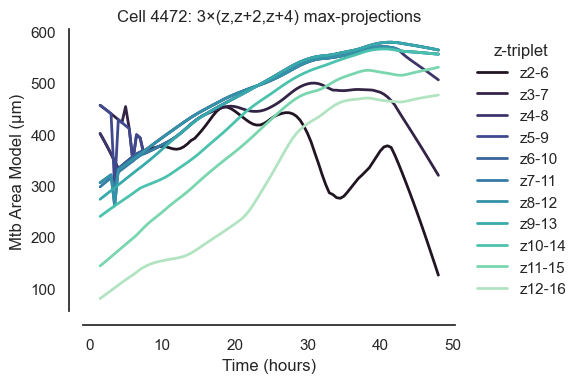

In [104]:

ID = 4472 
sc_df = df_proj[df_proj['ID_og']==ID].copy()
# --- Plot: one figure per cell ID ---
sns.set_theme(style="white")
plt.figure(figsize=(6,4))
ax = sns.lineplot(
    data=sc_df.dropna(subset=["Mtb Area Model (µm)"]),
    x="Time (hours)", y="Mtb Area Model (µm)",
    hue="proj_name", linewidth=2, palette="mako"
)
sns.despine(offset=10)
ax.set_title(f"Cell {ID}: 3×(z,z+2,z+4) max-projections")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Mtb Area Model (µm)")
ax.legend(title="z-triplet", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [213]:
largest_IDs = df.groupby("ID_og")["Mtb Area Model (µm)"].mean().nlargest(20).index.tolist()

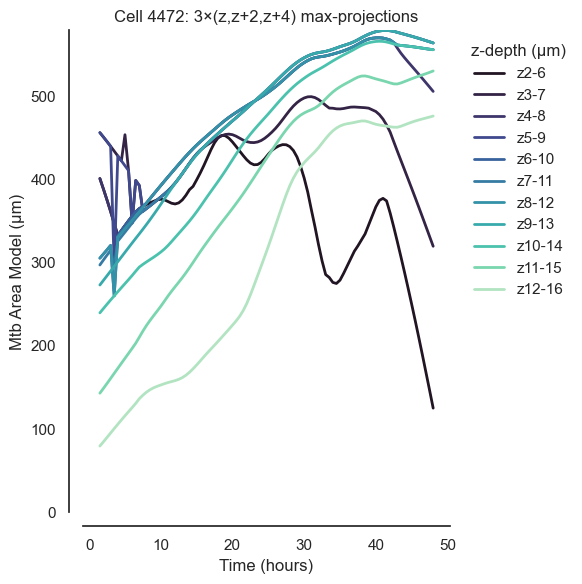

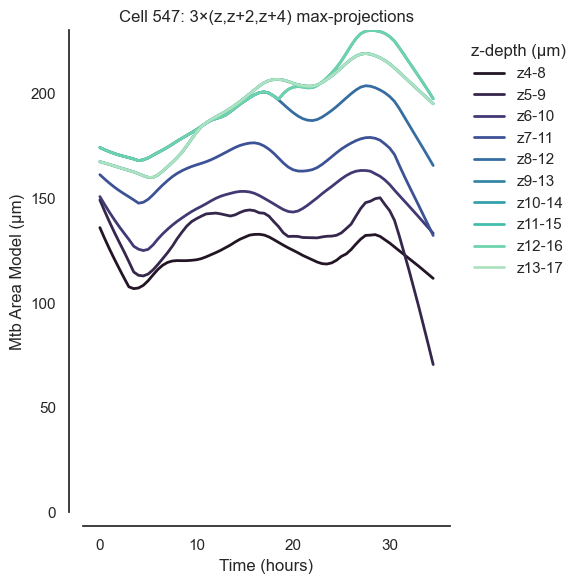

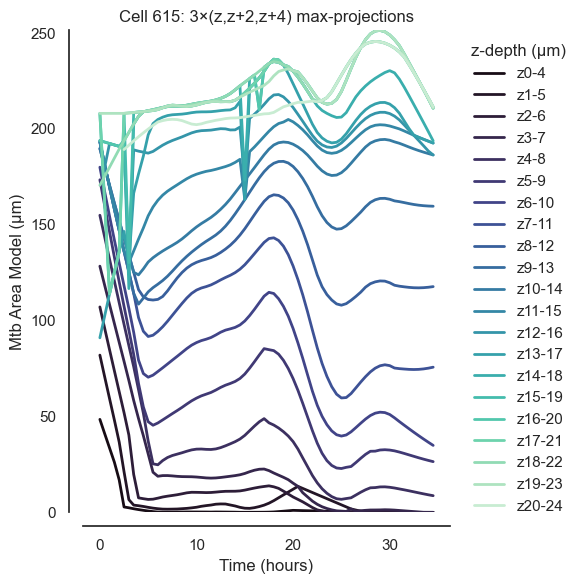

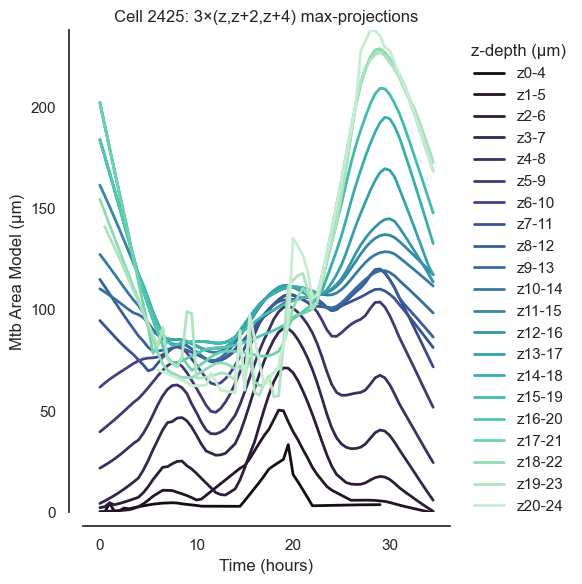

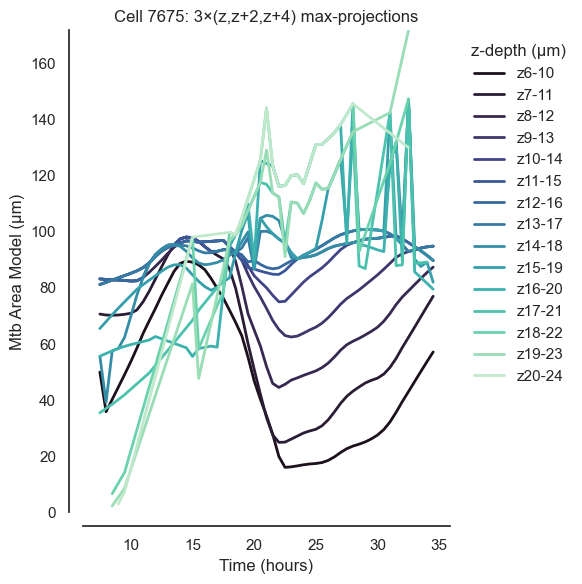

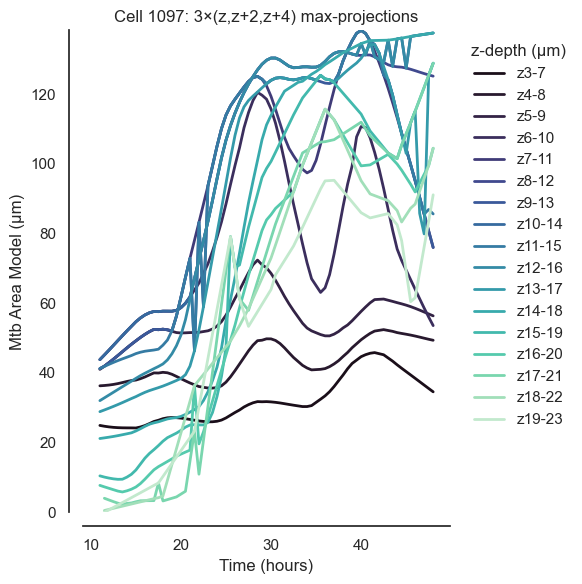

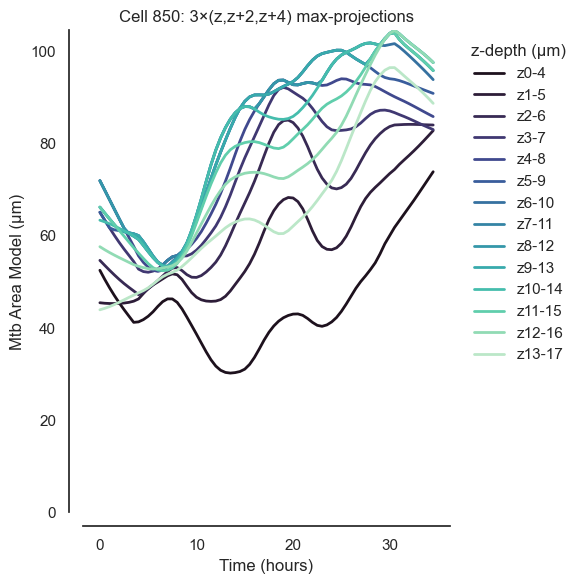

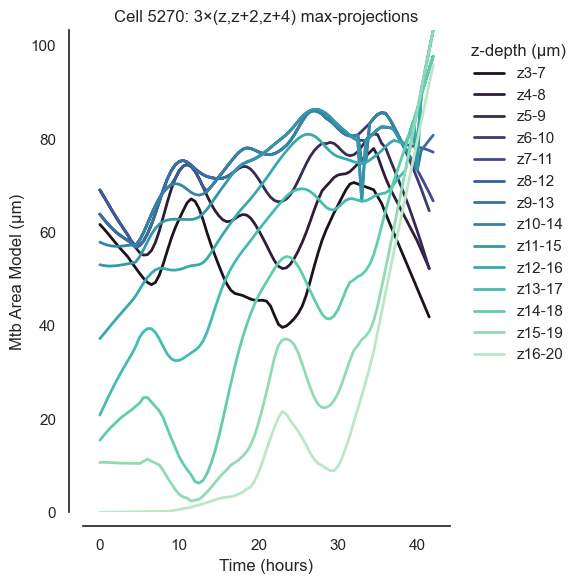

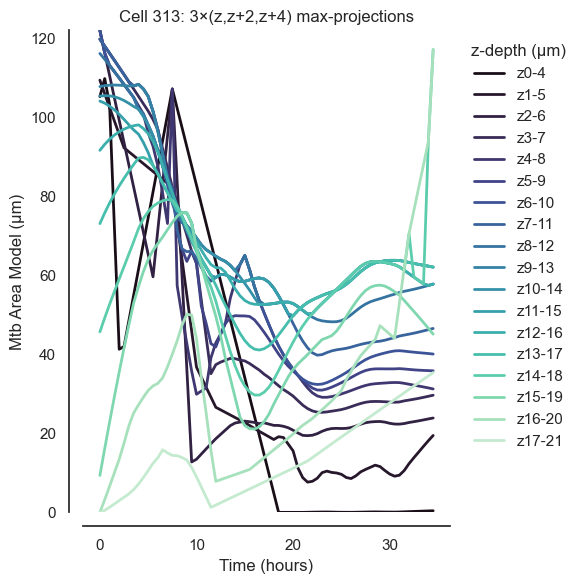

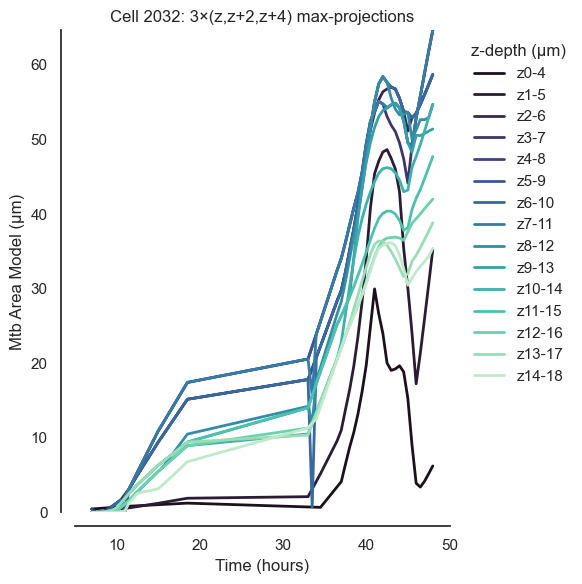

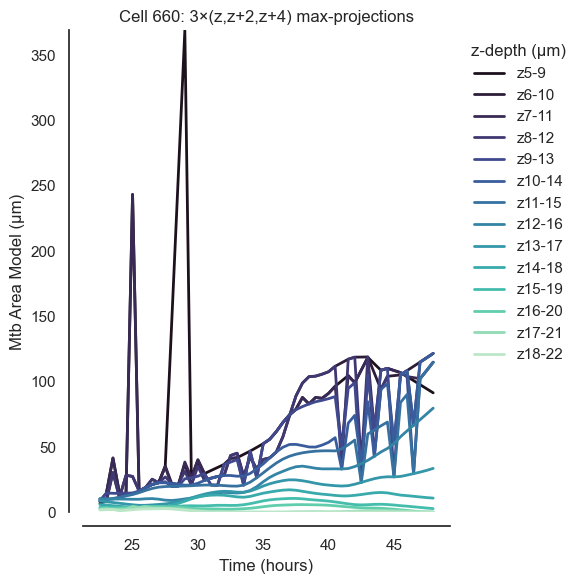

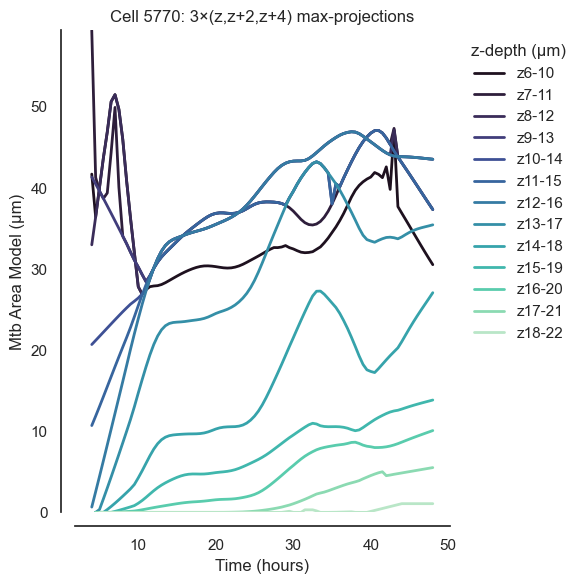

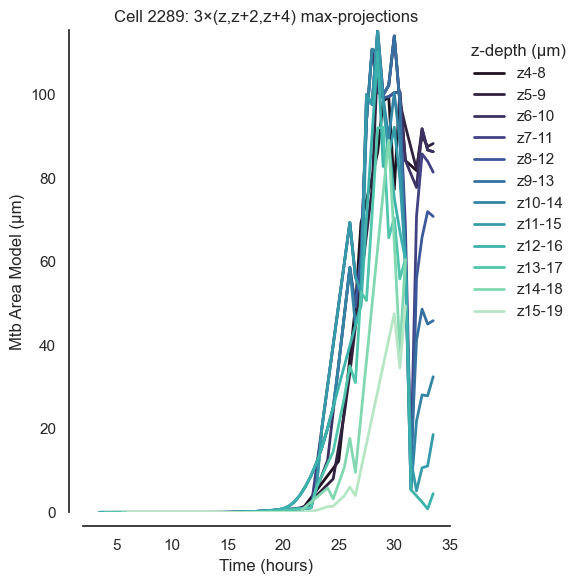

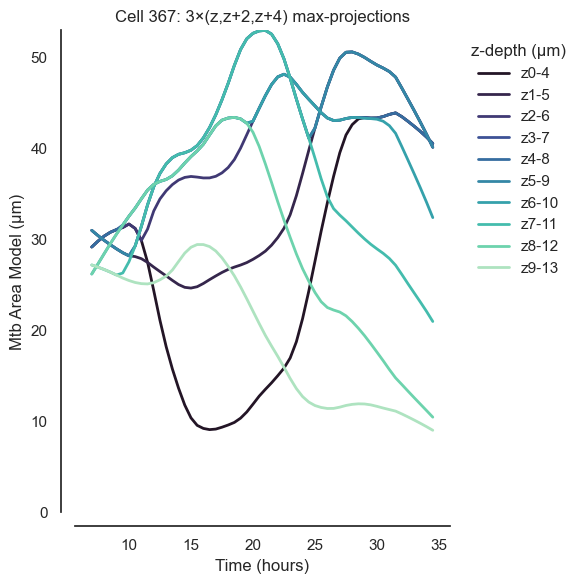

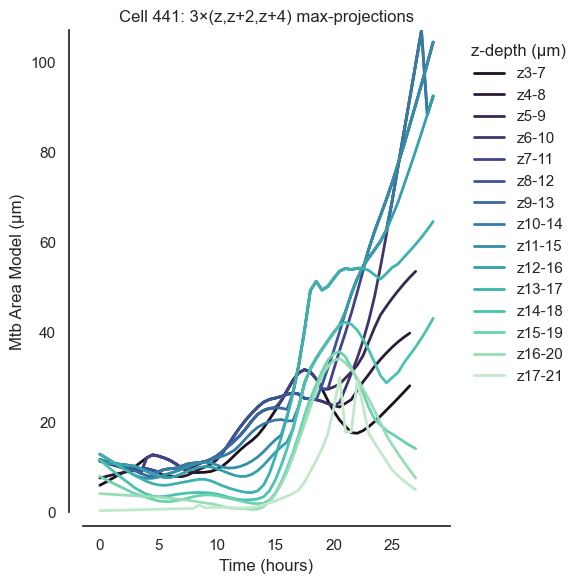

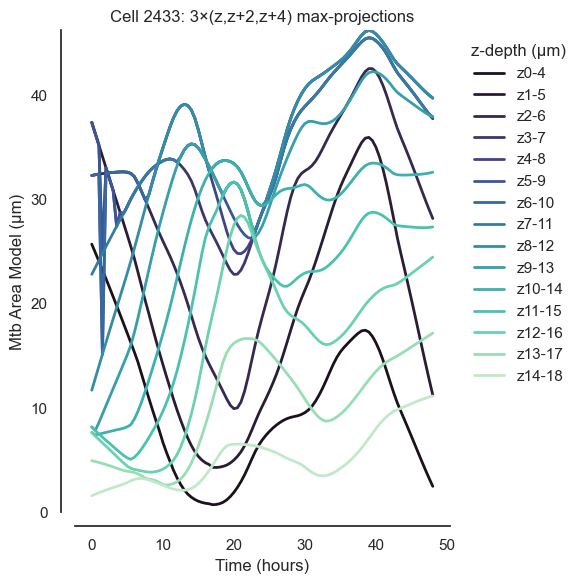

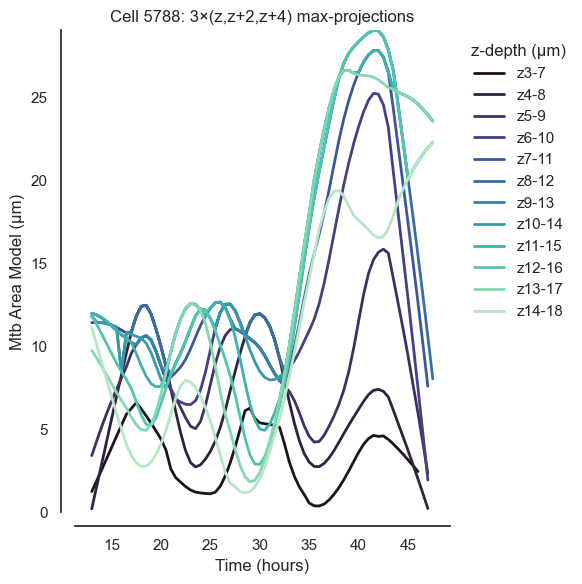

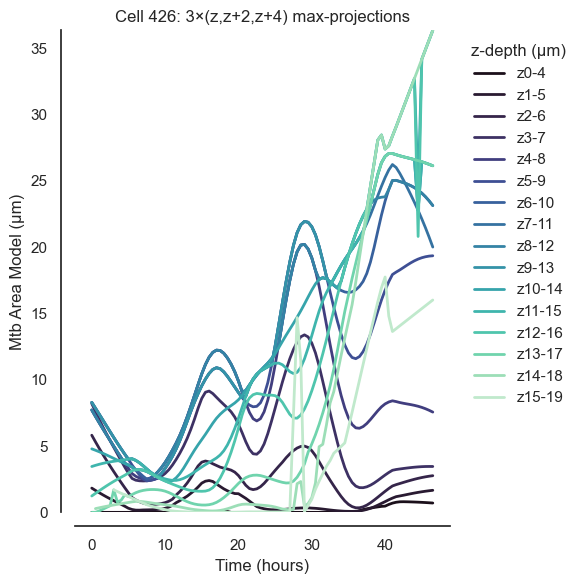

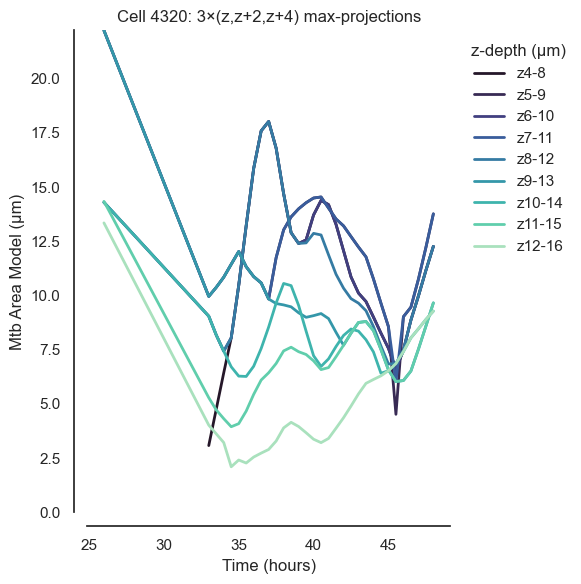

In [214]:
# os.mkdir('/Volumes/OPERA3/Nathan/Z_stack_tests/results/high_burden')
for ID in largest_IDs:
    
    sc_df = df_proj[df_proj['ID_og']==ID].copy()

    if len(sc_df['proj_name'].unique()) < 3:
        continue
    # --- Plot: one figure per cell ID ---
    sns.set_theme(style="white")
    plt.figure(figsize=(6,6))
    ax = sns.lineplot(
        data=sc_df.dropna(subset=["Mtb Area Model (µm)"]),
        x="Time (hours)", y="Mtb Area Model (µm)",
        hue="proj_name", linewidth=2, palette="mako"
    )
    sns.despine(offset=10)
    ax.set_title(f"Cell {ID}: 3×(z,z+2,z+4) max-projections")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Mtb Area Model (µm)")
    ax.legend(title="z-depth (µm)", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    ymax = sc_df["Mtb Area Model (µm)"].max()
    ax.set_ylim(0, ymax)
    plt.tight_layout()
    plt.savefig(f'/Volumes/OPERA3/Nathan/Z_stack_tests/results/high_burden/Cell ID {ID} across Z.pdf', dpi = 314, bbox_inches ='tight')
    plt.show()
    

In [215]:
low_IDs = (
    df.loc[(df["Mtb Area Model (µm)"] > 0) & (df["r2"] >= 0.7)]
      .groupby("ID_og")["Mtb Area Model (µm)"].mean()
      .nsmallest(20)
      .index.tolist()
)

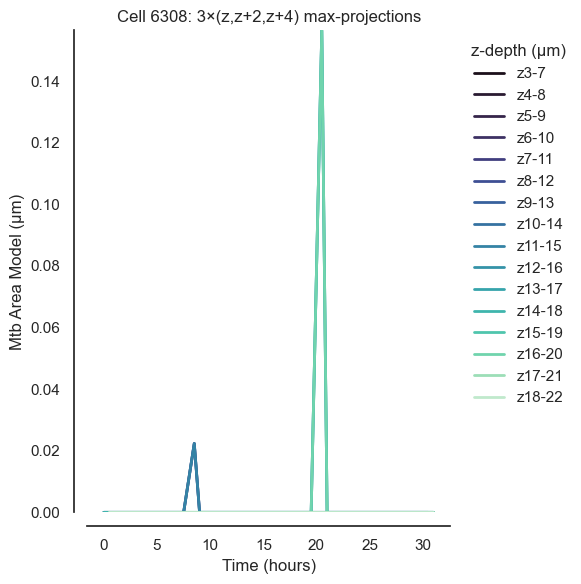

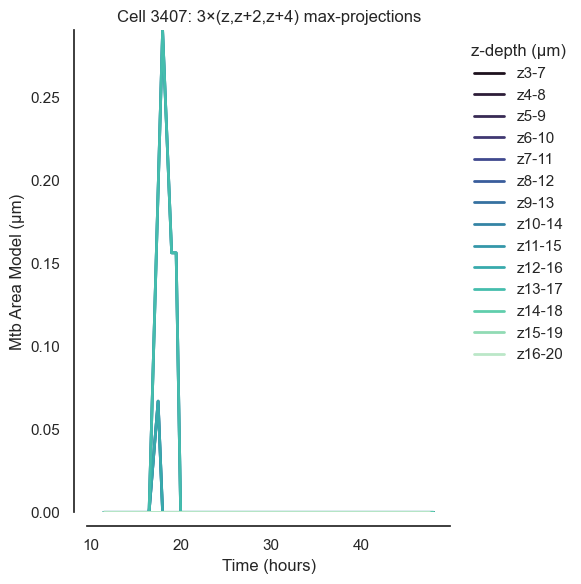

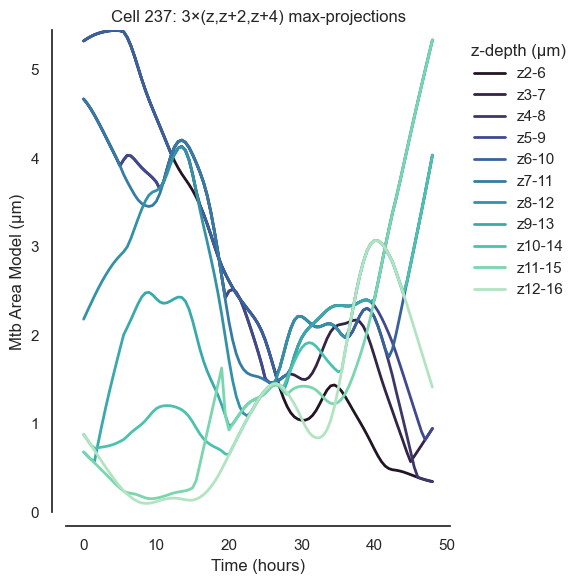

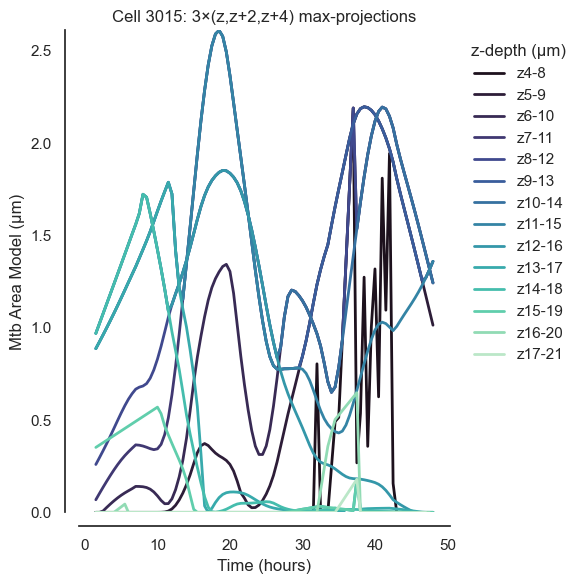

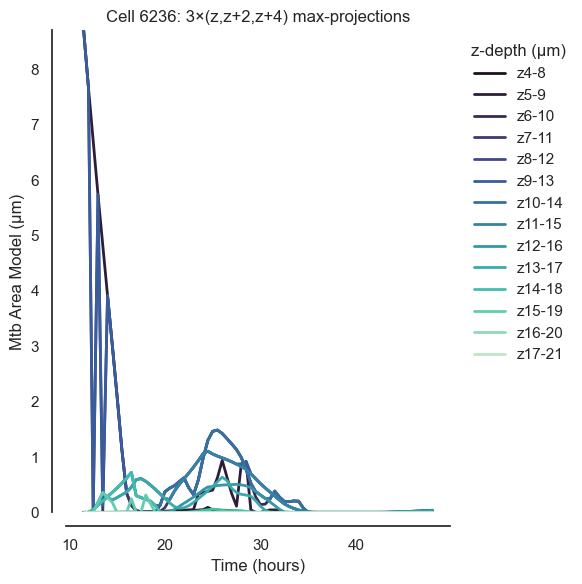

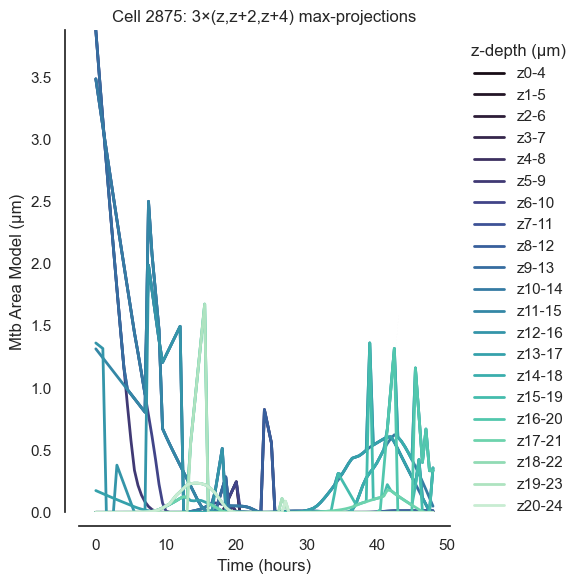

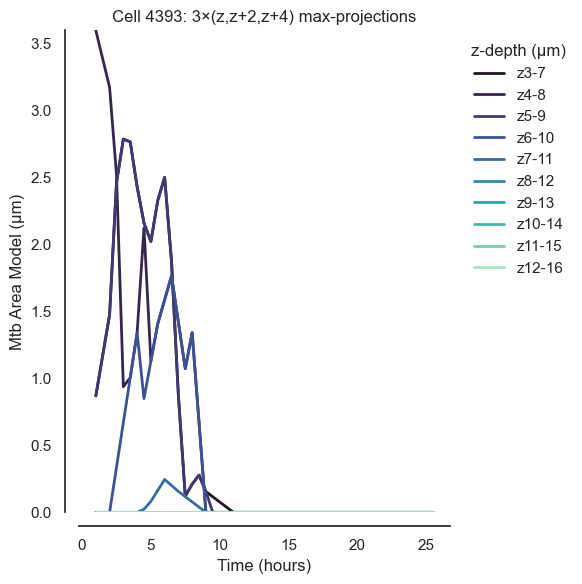

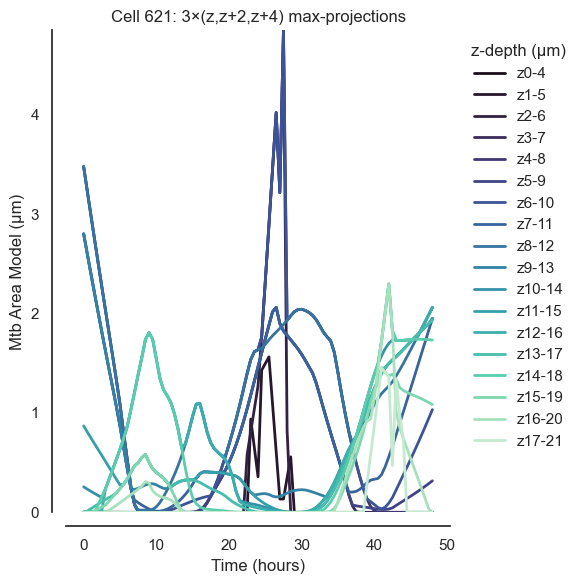

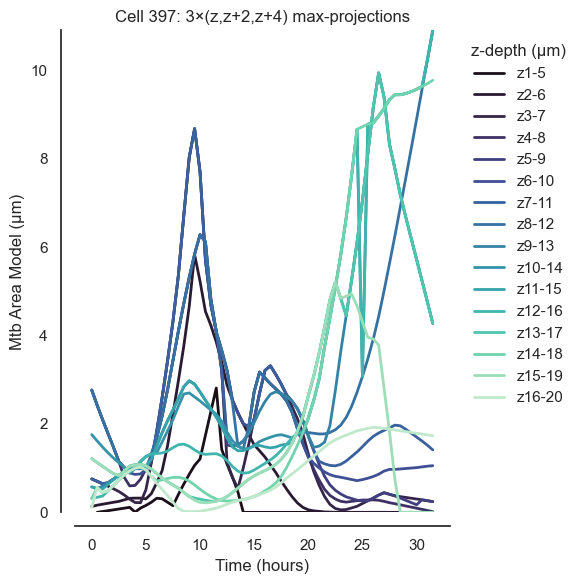

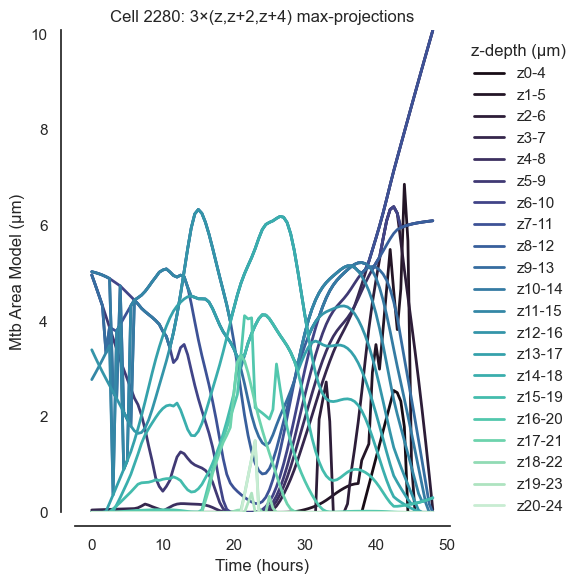

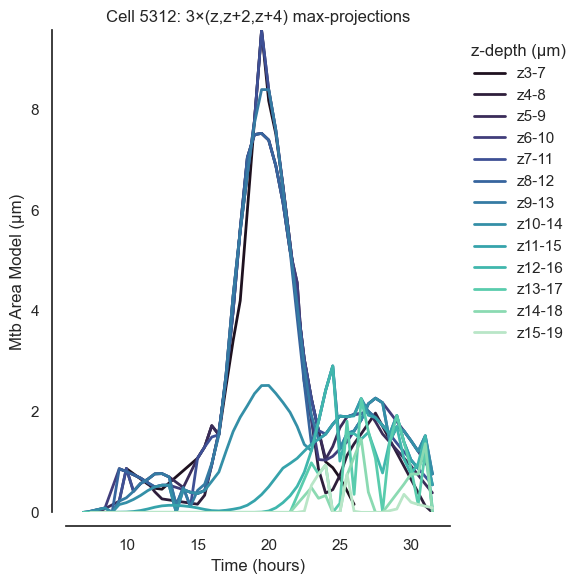

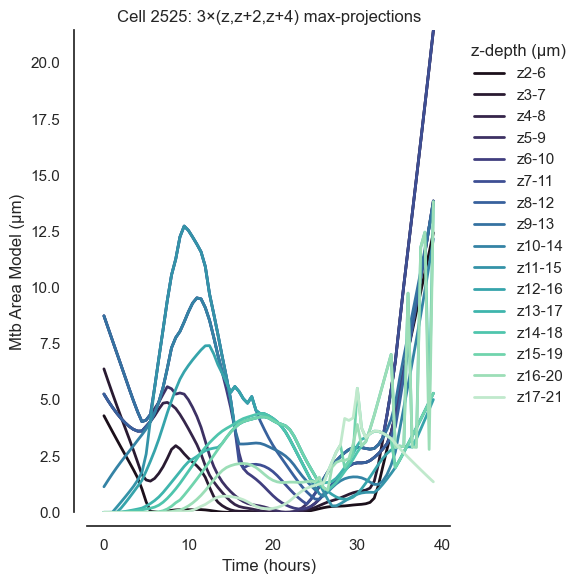

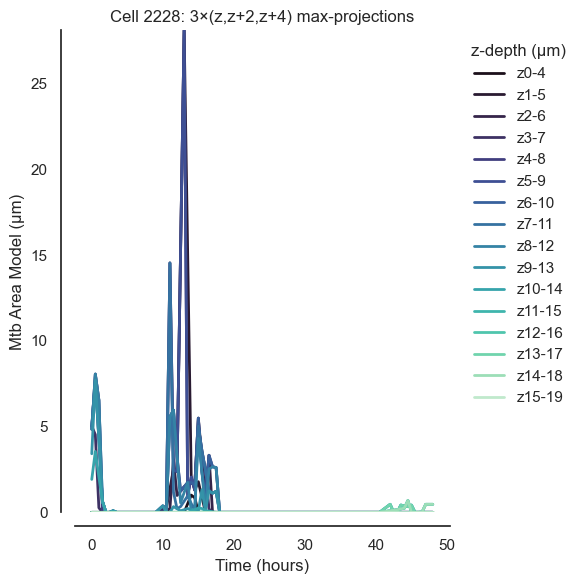

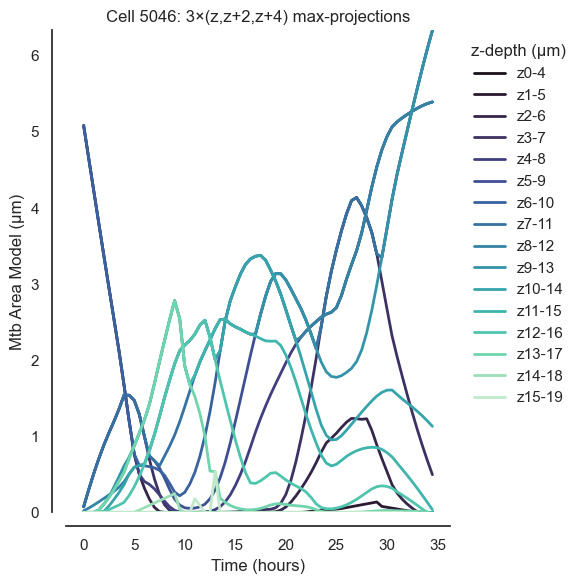

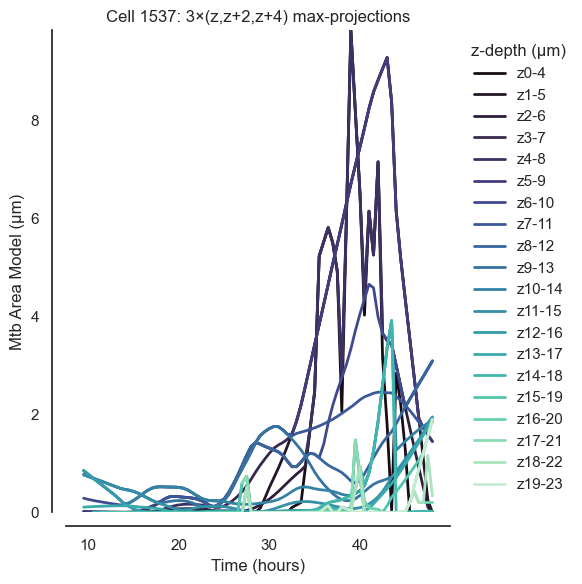

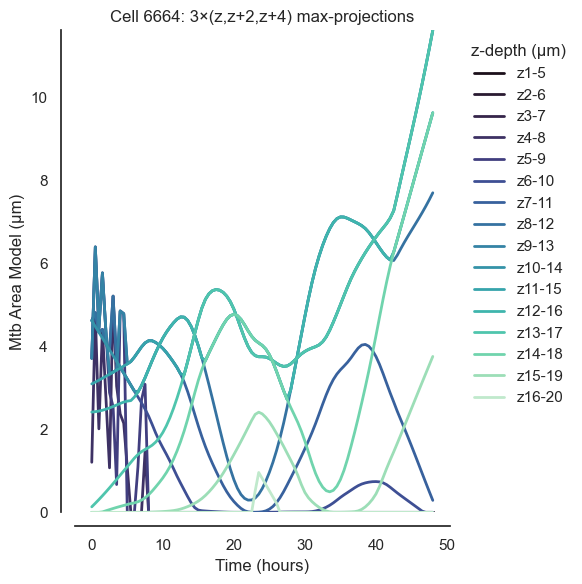

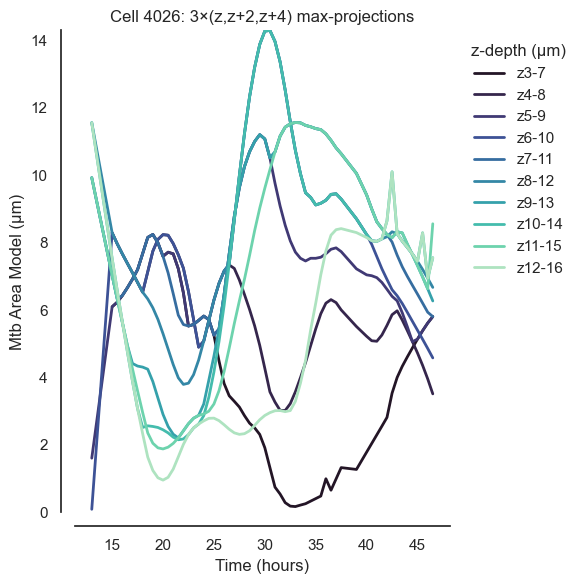

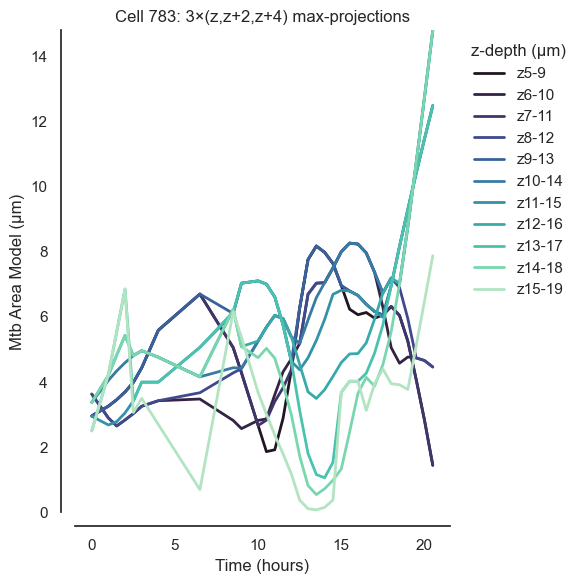

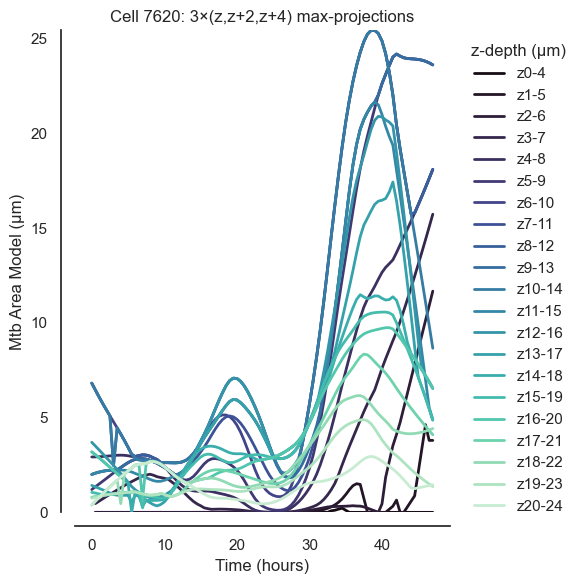

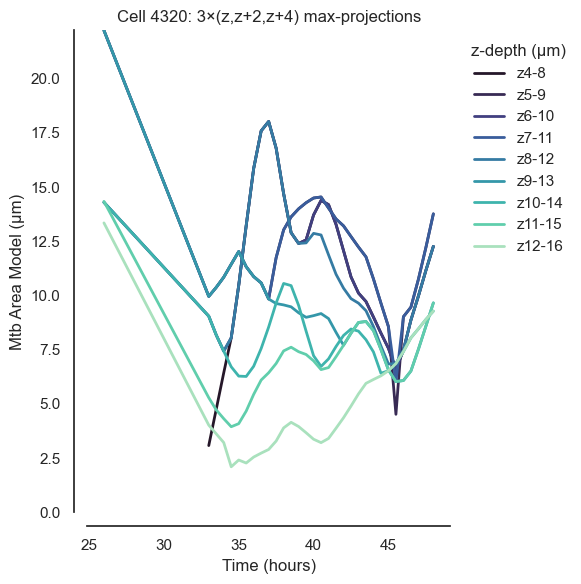

In [216]:
# os.mkdir('/Volumes/OPERA3/Nathan/Z_stack_tests/results/low_burden')
for ID in low_IDs:
    
    sc_df = df_proj[df_proj['ID_og']==ID].copy()

    if len(sc_df['proj_name'].unique()) < 3:
        continue
    # --- Plot: one figure per cell ID ---
    sns.set_theme(style="white")
    plt.figure(figsize=(6,6))
    ax = sns.lineplot(
        data=sc_df.dropna(subset=["Mtb Area Model (µm)"]),
        x="Time (hours)", y="Mtb Area Model (µm)",
        hue="proj_name", linewidth=2, palette="mako"
    )
    sns.despine(offset=10)
    ax.set_title(f"Cell {ID}: 3×(z,z+2,z+4) max-projections")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Mtb Area Model (µm)")
    ax.legend(title="z-depth (µm)", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    ymax = sc_df["Mtb Area Model (µm)"].max()
    ax.set_ylim(0, ymax)
    plt.tight_layout()
    plt.savefig(f'/Volumes/OPERA3/Nathan/Z_stack_tests/results/low_burden/Cell ID {ID} across Z.pdf', dpi = 314, bbox_inches ='tight')
    plt.show()
    

### Compute doubling metrics from growth model

In [220]:
r2_threshold = 0.7
min_area = 1.92
df = df.copy()

# df["Doubling Amounts"] = None
# df["Doubling Times"] = None
results = []

for ID in tqdm(df["ID"].unique(), desc="Doubling Metrics"):
    sc_df = df[df["ID"] == ID].dropna(
        subset=[
            "Time Model (hours)",
            "Mtb Area Model (\u00b5m)",
            "Mtb Area Processed (\u00b5m)",
        ]
    )
    if sc_df.empty:
        continue

    r2 = sc_df["r2"].iloc[0]
    if r2 < r2_threshold:
        continue

    min_val = max(sc_df["Mtb Area Model (\u00b5m)"].min(), min_area)
    max_val = sc_df["Mtb Area Model (\u00b5m)"].max()
    if max_val <= min_val:
        continue

    N_series = []
    N_i = min_val
    while N_i <= max_val:
        N_series.append(N_i)
        N_i *= 2

    if len(N_series) < 2:
        continue

    times = sc_df["Time Model (hours)"]
    model_vals = sc_df["Mtb Area Model (\u00b5m)"]

    doubling_idx = [np.abs(model_vals - val).idxmin() for val in N_series]
    doubling_times = (
        times.loc[doubling_idx].diff().dropna().values.tolist()
    )

    results.append(
        {
            "ID": ID,
            "Doubling Amounts": N_series,
            "Doubling Times": doubling_times,
        }
    )

results_df = pd.DataFrame(results)
# Merge results back into df by ID
df = df.merge(results_df, on="ID", how="left")


Doubling Metrics:   0%|          | 0/1241 [00:00<?, ?it/s]

In [223]:
df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),ID_og,Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2,Doubling Amounts,Doubling Times
0,0,237_1,1,1411,1358,8900,0,1195,3,3,0.0,0.0,237,NaN,NaN,NaN,NaN,NaN,NaN
1,0,237_2,2,1411,1358,14025,0,1195,3,3,0.0,0.0,237,0.0,0.0,0.000000,1.000000,NaN,NaN
2,0,237_3,3,1411,1358,11500,0,1195,3,3,0.0,0.0,237,0.0,0.0,0.000000,-0.062923,NaN,NaN
3,0,237_4,4,1411,1358,11175,0,1195,3,3,0.0,0.0,237,0.0,0.0,0.025363,0.299080,NaN,NaN
4,0,237_5,5,1411,1358,16000,0,1195,3,3,0.0,0.0,237,0.0,0.0,1.253830,0.569817,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58549,96,7546_11,11,1841,610,11100,0,163,3,3,0.0,48.0,7546,0.0,48.0,0.000000,1.000000,NaN,NaN
58550,96,7546_12,12,1841,610,10850,0,163,3,3,0.0,48.0,7546,0.0,48.0,0.000000,1.000000,NaN,NaN
58551,96,7546_13,13,1841,610,9975,0,163,3,3,0.0,48.0,7546,0.0,48.0,0.000000,1.000000,NaN,NaN
58552,96,7546_14,14,1841,610,8250,0,163,3,3,0.0,48.0,7546,0.0,48.0,0.000000,1.000000,NaN,NaN


<Axes: xlabel='Doubling Times', ylabel='Count'>

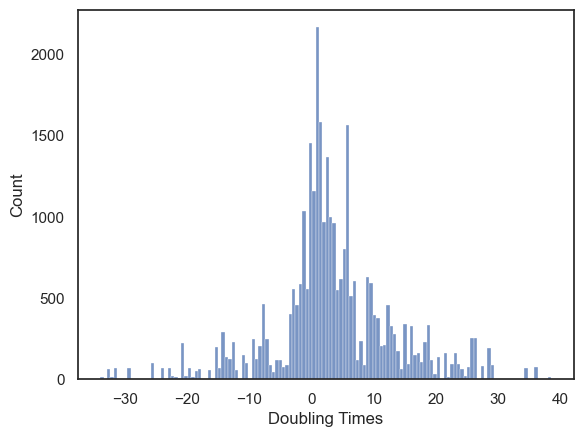

In [188]:
sns.histplot(df['Doubling Times'].explode())

In [237]:
def maxproj_stride2_with_doubling(df, length=3, step=2, min_points=1, min_area=1.92):
    """
    Build 3-slice max-projections separated by 2 µm: (z, z+2, z+4),
    then compute doubling amounts/times from EACH projected curve.

    Returns ONE long DataFrame with columns:
      ['ID_og','Time (hours)','proj_name','Mtb Area Model (µm)',
       'Doubling Amounts','Doubling Times']

    Notes:
      - Expects columns exactly: 'ID_og','z','Time (hours)','Mtb Area Model (µm)'.
      - 'Doubling Amounts' and 'Doubling Times' are lists repeated on all rows
        for the corresponding (ID_og, proj_name).
    """
    rows = []

    for gid, g in df.groupby("ID_og"):
        grid = (
            g.pivot_table(index="Time (hours)", columns="z",
                          values="Mtb Area Model (µm)", aggfunc="max")
             .sort_index(axis=1)
        )
        if grid.empty:
            continue

        z_vals = sorted(pd.Index(grid.columns).astype(int).tolist())
        starts = [z for z in z_vals if all((z + k*step) in z_vals for k in range(length))]

        for z0 in starts:
            cols = [z0 + k*step for k in range(length)]  # z, z+2, z+4
            proj = grid[cols].max(axis=1, skipna=True)
            if proj.notna().sum() < min_points:
                continue

            # --- doubling metrics on the projected curve ---
            s = proj.dropna()
            times = s.index.to_numpy(dtype=float)
            values = s.values.astype(float)

            if s.empty:
                dbl_amounts, dbl_times = [], []
            else:
                vmin = max(values.min(), float(min_area))
                vmax = values.max()
                if vmax <= vmin:
                    dbl_amounts, dbl_times = [], []
                else:
                    targets = []
                    x = vmin
                    while x <= vmax + 1e-12:
                        targets.append(x)
                        x *= 2.0
                    if len(targets) < 2:
                        dbl_amounts, dbl_times = targets, []
                    else:
                        idx_for_target = np.array(
                            [np.argmin(np.abs(values - t)) for t in targets], dtype=int
                        )
                        # de-duplicate plateaus; keep chronological order
                        _, uniq_pos = np.unique(idx_for_target, return_index=True)
                        idx_for_target = idx_for_target[np.sort(uniq_pos)]
                        dbl_times = np.diff(times[idx_for_target]).tolist()
                        dbl_amounts = targets

            # --- long-form rows for this projection (repeat lists per row) ---
            tmp = proj.reset_index()
            tmp.columns = ["Time Model (hours)", "Mtb Area Model (µm)"]
            tmp["ID_og"] = gid
            tmp["proj_name"] = f"z{cols[0]}-{cols[-1]}"
            n = len(tmp)
            tmp["Doubling Amounts"] = [dbl_amounts] * n
            tmp["Doubling Times"] = [dbl_times] * n
            rows.append(tmp[["ID_og","Time Model (hours)","proj_name",
                             "Mtb Area Model (µm)","Doubling Amounts","Doubling Times"]])

    return pd.concat(rows, ignore_index=True) if rows else df.iloc[0:0].copy()
to_plot = maxproj_stride2_with_doubling(df, length=3, step=2, min_points=2, min_area=1.92)


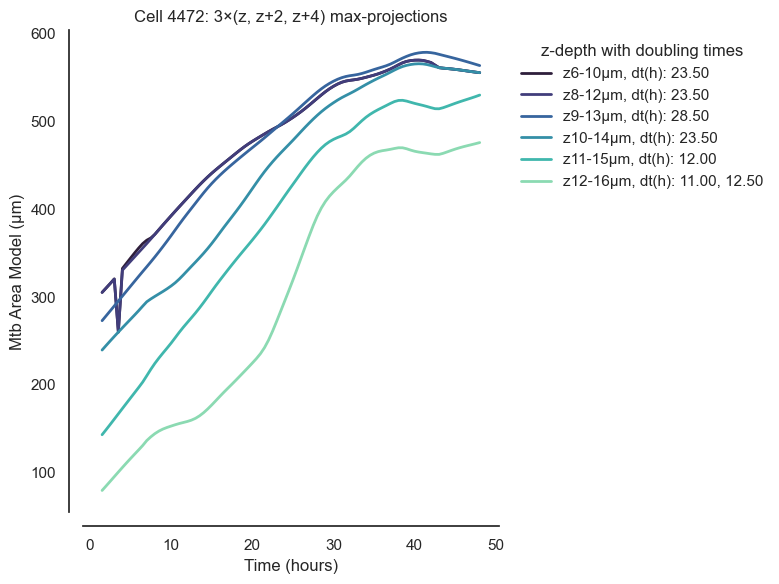

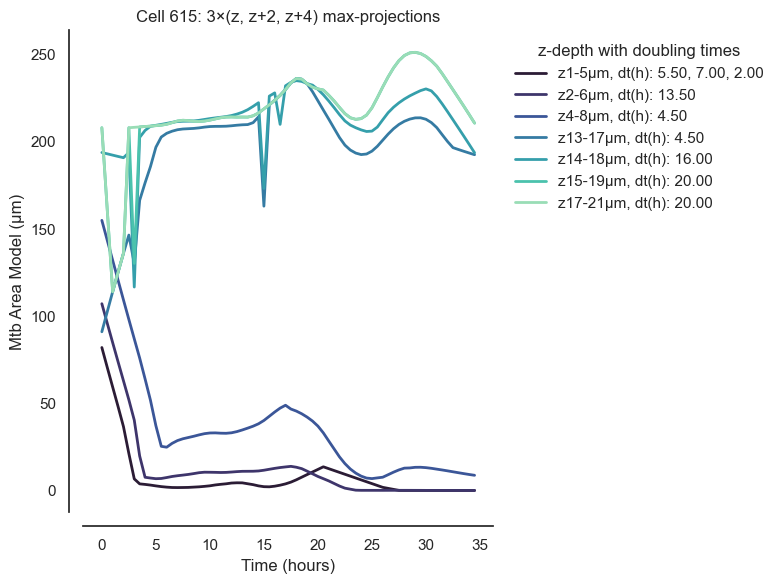

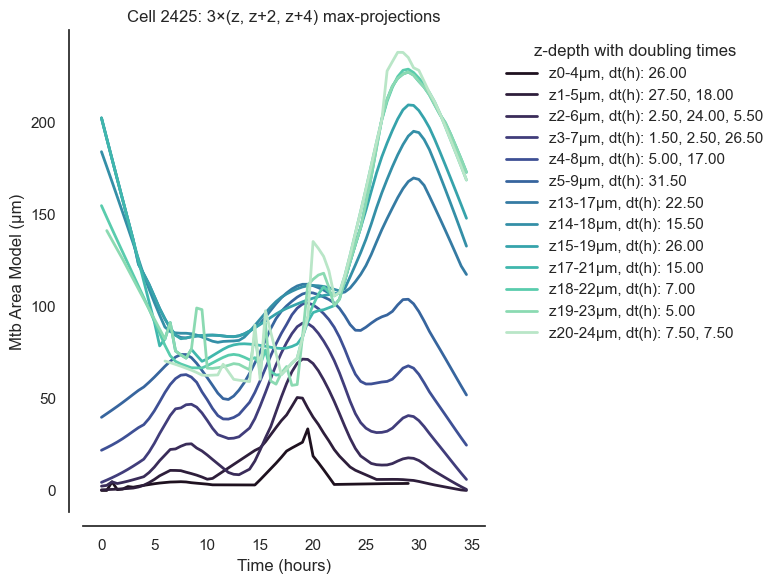

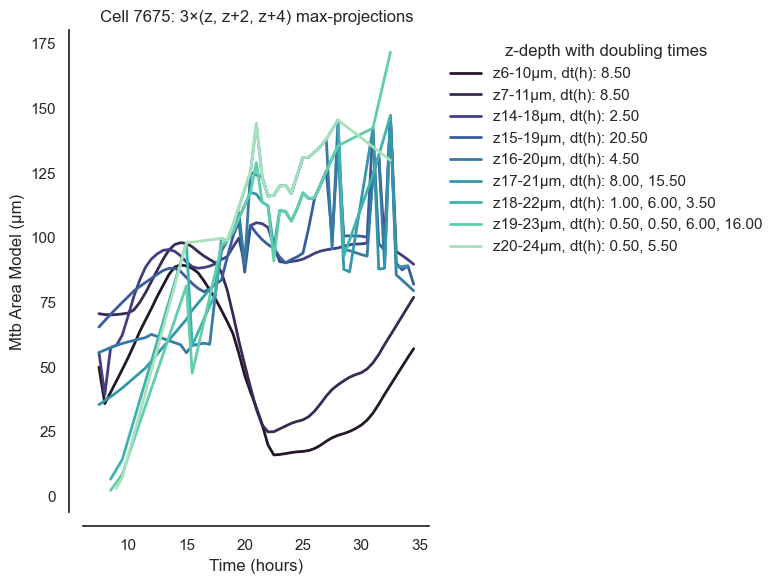

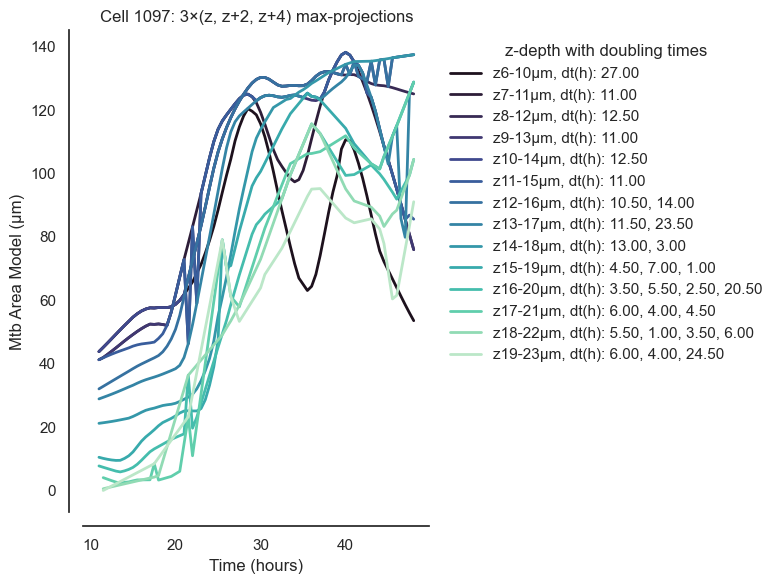

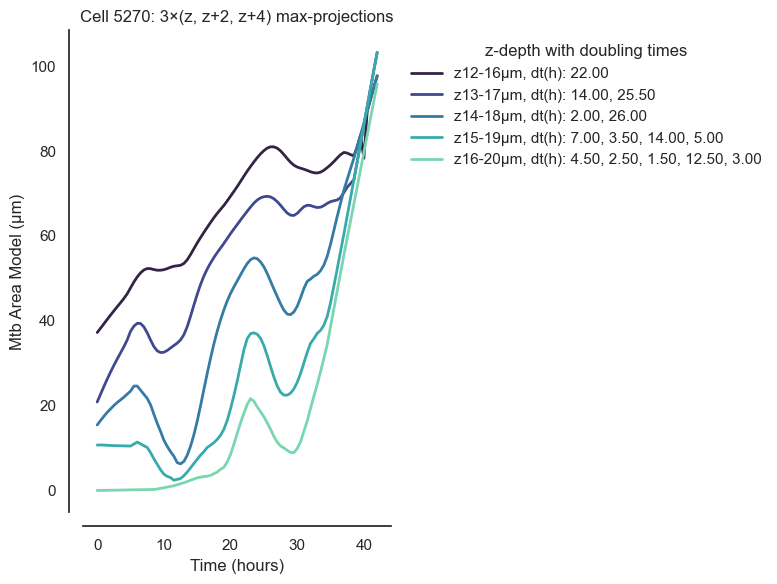

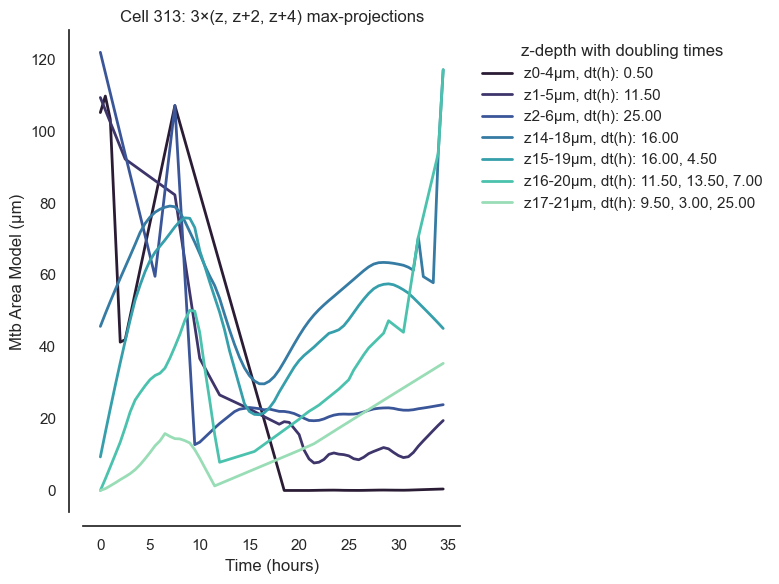

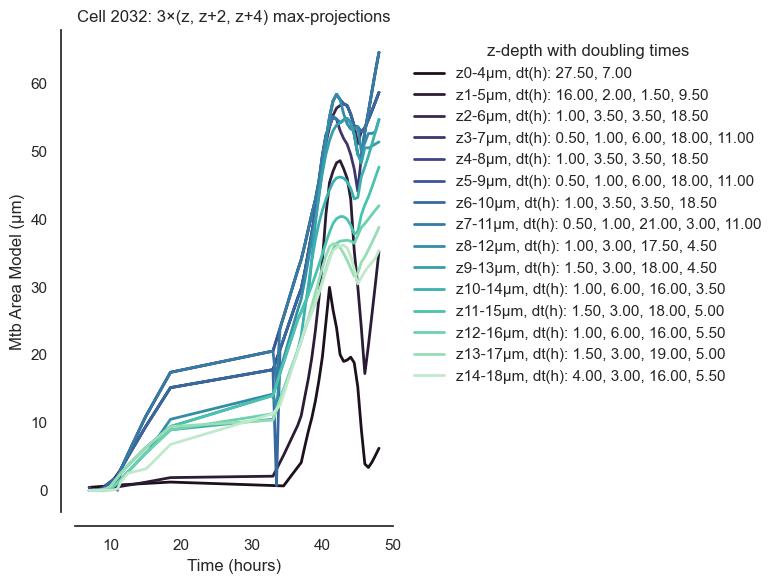

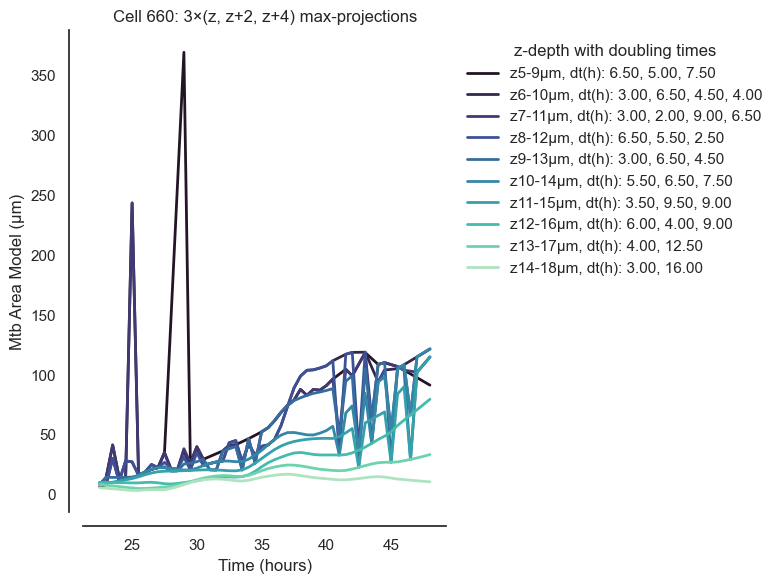

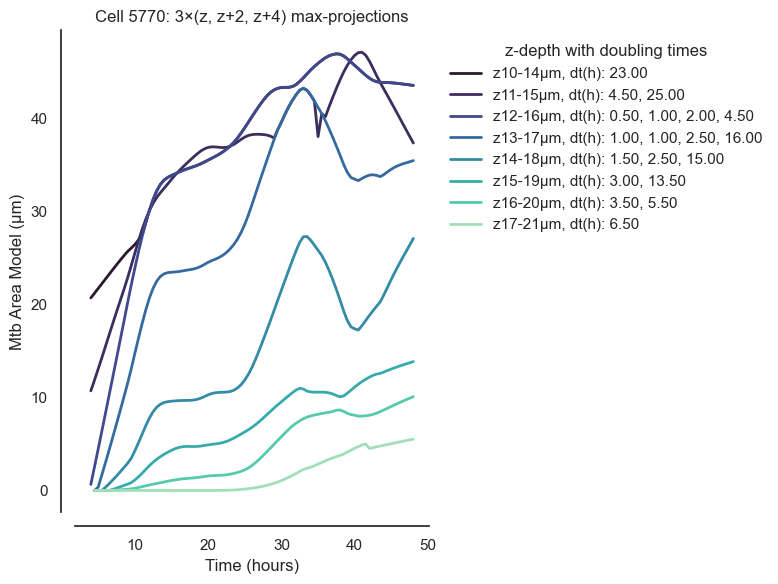

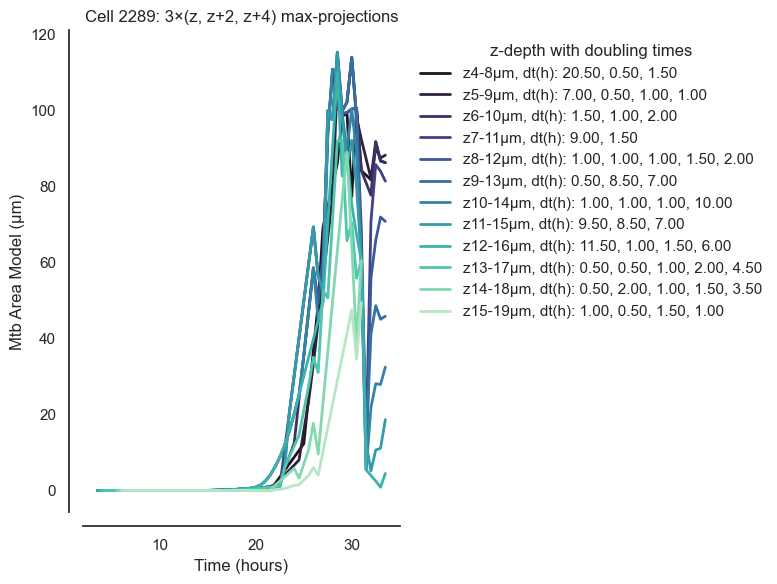

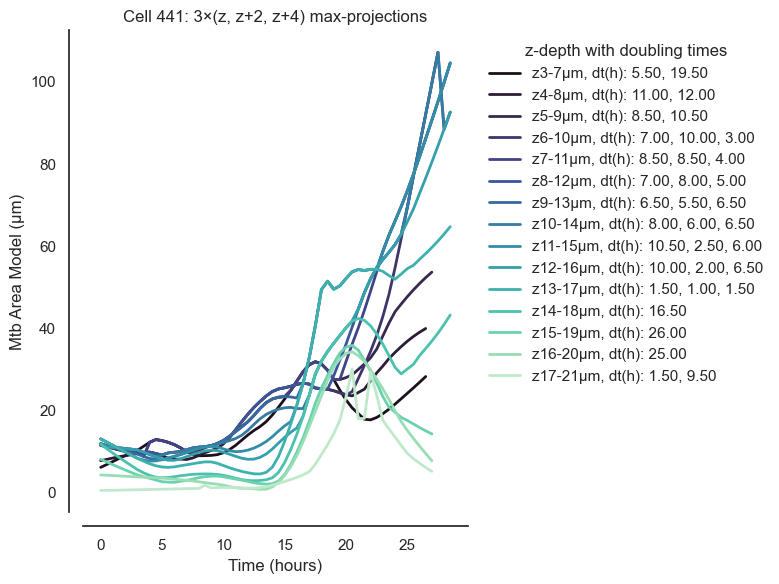

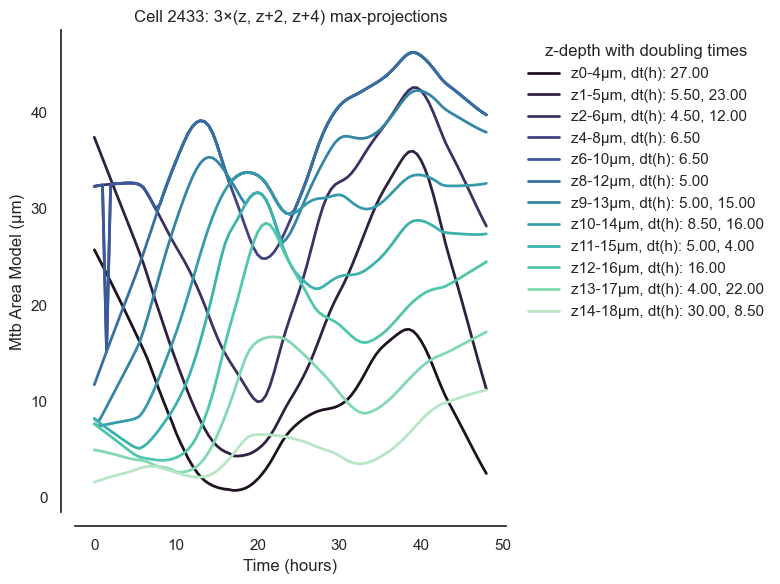

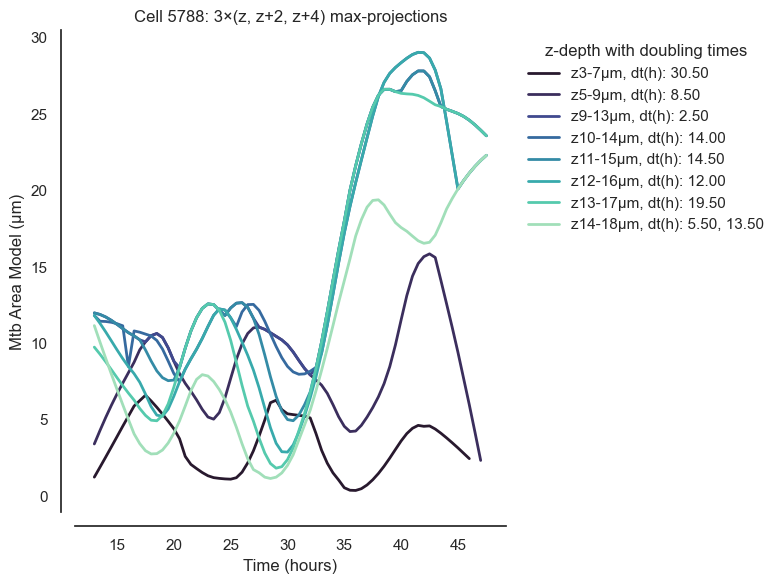

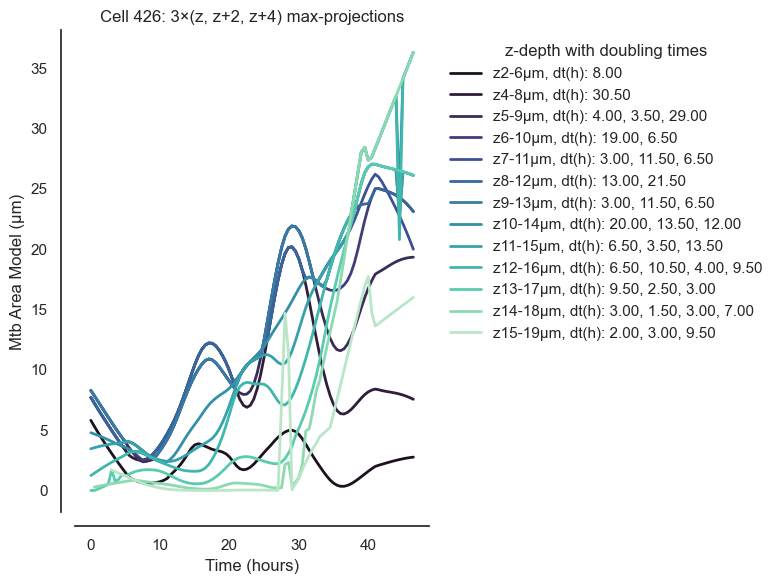

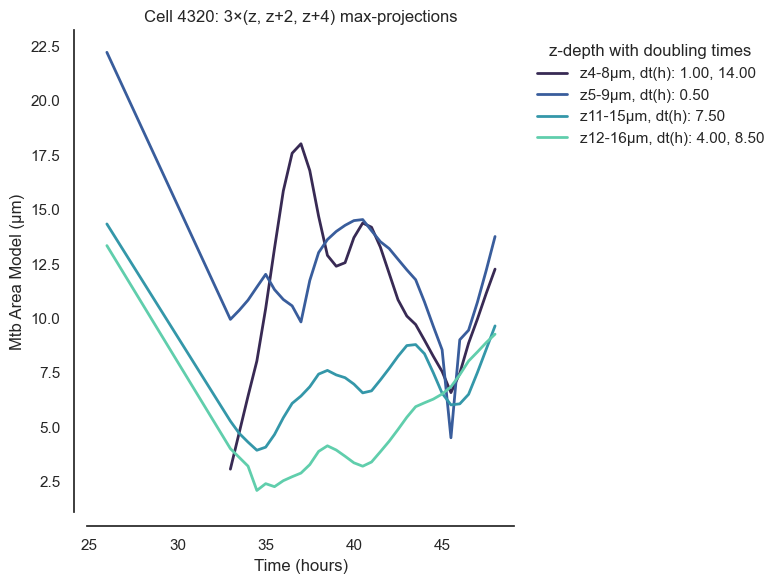

In [238]:

# only keep positive dts
to_plot["Doubling Times"] = to_plot["Doubling Times"].apply(
    lambda x: [dt for dt in x if dt > 0] if isinstance(x, list) else x
)
to_plot = to_plot[to_plot["Doubling Times"].apply(lambda x: isinstance(x, list) and len(x) > 0)]

os.makedirs('/Volumes/OPERA3/Nathan/Z_stack_tests/results/high_burden_w_dts', exist_ok=True)

sns.set_theme(style="white")
for ID in largest_IDs:
    sc = to_plot[to_plot['ID_og'] == ID].copy()
    if sc["proj_name"].nunique() < 3:
        continue

    # build pretty legend labels including doubling times per triplet
    def lbl(row):
        dts = row["Doubling Times"]
        if isinstance(dts, list) and len(dts) > 0:
            dt_str = ", ".join(f"{x:.2f}" for x in dts)
            return f"{row['proj_name']}µm, dt(h): {dt_str}"
        return f"{row['proj_name']}µm, dt(h): n/a"

    # one label per proj_name
    label_map = (sc.drop_duplicates(['ID_og', "proj_name"])
                   .assign(label=lambda x: x.apply(lbl, axis=1))
                   .set_index("proj_name")["label"].to_dict())
    sc["label"] = sc["proj_name"].map(label_map)

    plt.figure(figsize=(8,6))
    ax = sns.lineplot(
        data=sc.dropna(subset=[AREA_COL]),
        x=TIME_COL, y=AREA_COL,
        hue="label", linewidth=2, palette="mako"
    )
    sns.despine(offset=10)
    ax.set_title(f"Cell {ID}: 3×(z, z+2, z+4) max-projections")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel(AREA_COL)

    # tight y-limits per cell to fully use vertical space
    # y = sc[AREA_COL].to_numpy(dtype=float)
    # if np.isfinite(y).any():
    #     ymin, ymax = np.nanmin(y), np.nanmax(y)
    #     pad = 0.03 * max(ymax - ymin, 1.0)
    #     ax.set_ylim(ymin - pad, ymax + pad)
    ax.legend(title="z-depth with doubling times", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    # save if you like:

    # plt.savefig(f'/Volumes/OPERA3/Nathan/Z_stack_tests/results/high_burden_w_dts/Cell ID {ID} across Z.pdf', dpi = 314, bbox_inches ='tight')
    plt.show()

# Save out subset tiff files or try loading subset associated with largest_IDs

In [239]:
largest_IDs

[4472,
 451,
 547,
 615,
 2425,
 7675,
 1097,
 850,
 5270,
 313,
 2032,
 660,
 5770,
 2289,
 367,
 441,
 2433,
 5788,
 426,
 4320]

In [248]:
from pathlib import Path
import numpy as np
import pandas as pd
import dask.array as da

def crop_xy_track_volume(
    df: pd.DataFrame,
    root_dir: str,
    ID: int | str,
    size_xy: tuple[int, int] = (256, 256),
):
    """
    Return a lazy Dask volume that follows a single cell (ID_og == ID) in XY.
    - Keeps FULL Z (no Z cropping)
    - Crops a fixed (H, W) window per frame centered on the cell
    - Assumes NGFF store: (row,col).zarr / images / 0  -> shape (T, C, Z, Y, X)
      and df has columns: ['ID_og','row','col','t','y','x'] (pixel coords)

    Returns
    -------
    sub : dask.array, shape (T, C, Z, H, W)
    info : dict with metadata (source, shapes, per-frame boxes)
    """
    H, W = map(int, size_xy)
    g = df[df["ID_og"] == ID].copy()
    if g.empty:
        raise ValueError(f"ID_og={ID} not found")

    row, col = int(g["row"].iloc[0]), int(g["col"].iloc[0])
    store = Path(root_dir) / f"({row},{col}).zarr"
    img = da.from_zarr(str(store / "images" / "0"))   # (T, C, Z, Y, X)

    if img.ndim != 5:
        raise ValueError(f"Expected (T,C,Z,Y,X); got shape {img.shape}")

    T, C, Z, Y, X = map(int, img.shape)

    # one (y,x) center per t; fill gaps fwd/bwd; default to image center
    centers = (
        g.groupby("t")[["y","x"]].mean().round().astype(int)
         .reindex(range(T))
    )
    centers["y"] = centers["y"].ffill().bfill().fillna(Y//2).astype(int)
    centers["x"] = centers["x"].ffill().bfill().fillna(X//2).astype(int)

    hy, hx = H // 2, W // 2
    boxes = []
    for t in range(T):
        cy, cx = int(centers.at[t, "y"]), int(centers.at[t, "x"])
        y0 = np.clip(cy - hy, 0, max(0, Y - H))
        x0 = np.clip(cx - hx, 0, max(0, X - W))
        boxes.append((int(y0), int(y0 + H), int(x0), int(x0 + W)))

    # build lazy stack (keep FULL Z)
    frames = [img[t, :, :, y0:y1, x0:x1] for t, (y0, y1, x0, x1) in enumerate(boxes)]
    sub = da.stack(frames, axis=0)  # (T, C, Z, H, W)

    info = {
        "source": str(store / "images" / "0"),
        "ID_og": int(ID),
        "field": (row, col),
        "source_shape": tuple(img.shape),
        "crop_shape": tuple(sub.shape),
        "boxes_t": boxes,
        "size_xy": (H, W),
    }
    return sub, info

In [249]:
sub, info = crop_xy_track_volume(
    df=df,
    root_dir="/Volumes/OPERA3/Nathan/Z_stack_tests/zarr",
    ID=4472,
    size_xy=(500, 500),
)

# Optionally write to Zarr
# sub.to_zarr("/Volumes/OPERA3/Nathan/Z_stack_tests/crops/ID_4472_follow.zarr", component="0", overwrite=True)

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_72879/104769487.py:56: PerformanceWarning: Increasing number of chunks by factor of 404
  sub = da.stack(frames, axis=0)  # (T, C, Z, H, W)


In [ ]:
%%time
loaded_image_crop = sub.compute()

In [ ]:
viewer = napari.Viewer(title = 'testing crops')
viewer.add_image(loaded_image_crop, channel_axis = 1)

# Plot all dt with ID colour code

# Prev arx

In [241]:
df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),ID_og,Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2,Doubling Amounts,Doubling Times
0,0,237_1,1,1411,1358,8900,0,1195,3,3,0.0,0.0,237,NaN,NaN,NaN,NaN,NaN,NaN
1,0,237_2,2,1411,1358,14025,0,1195,3,3,0.0,0.0,237,0.0,0.0,0.000000,1.000000,NaN,NaN
2,0,237_3,3,1411,1358,11500,0,1195,3,3,0.0,0.0,237,0.0,0.0,0.000000,-0.062923,NaN,NaN
3,0,237_4,4,1411,1358,11175,0,1195,3,3,0.0,0.0,237,0.0,0.0,0.025363,0.299080,NaN,NaN
4,0,237_5,5,1411,1358,16000,0,1195,3,3,0.0,0.0,237,0.0,0.0,1.253830,0.569817,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58549,96,7546_11,11,1841,610,11100,0,163,3,3,0.0,48.0,7546,0.0,48.0,0.000000,1.000000,NaN,NaN
58550,96,7546_12,12,1841,610,10850,0,163,3,3,0.0,48.0,7546,0.0,48.0,0.000000,1.000000,NaN,NaN
58551,96,7546_13,13,1841,610,9975,0,163,3,3,0.0,48.0,7546,0.0,48.0,0.000000,1.000000,NaN,NaN
58552,96,7546_14,14,1841,610,8250,0,163,3,3,0.0,48.0,7546,0.0,48.0,0.000000,1.000000,NaN,NaN


/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_72879/3646134073.py:31: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


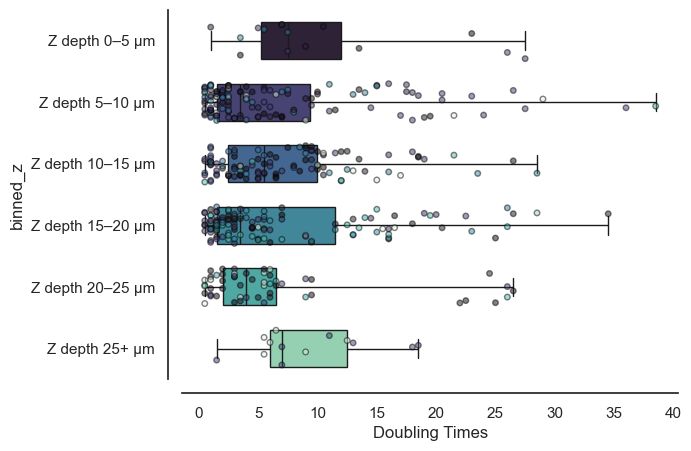

In [245]:
subset_df = (
    df.drop_duplicates(subset="ID")
      .dropna(subset=["Doubling Times"])
      .explode(["Doubling Times"])
)

subset_df = subset_df if subset_df ID in largest IDs
subset_df = subset_df[(subset_df['Doubling Times'] > 0) &
                      (subset_df['r2'] >= 0.7)]

labels = [
    "Z depth 0–5 µm",
    "Z depth 5–10 µm",
    "Z depth 10–15 µm",
    "Z depth 15–20 µm",
    "Z depth 20–25 µm",
    "Z depth 25+ µm"
]

subset_df["binned_z"] = pd.cut(subset_df["z"], bins=6, labels=labels)

sns.boxplot(
    data=subset_df,
    x="Doubling Times", 
    y="binned_z", 
    hue="binned_z", 
    whis=[0, 100], width=0.6,
    palette='mako',
    # legend=True
)

sns.stripplot(
    data=subset_df, x="Doubling Times", size=4, hue="ID_og", y="binned_z",
    palette='mako', alpha=0.5,
    edgecolor='gray', linewidth=1, jitter=0.3, legend=False
    
)
sns.despine(offset=10)



In [492]:
for layer in viewer_2.layers:
    layer.scale = [1, 0.14949, 0.14949]

In [494]:
# --- Scale bar settings ---
viewer_2.scale_bar.visible = True
viewer_2.scale_bar.unit = "µm"
viewer_2.scale_bar.position = "bottom_right"
viewer_2.scale_bar.font_size = 20
viewer_2.scale_bar.color = "white"
viewer_2.scale_bar.ticks = False  # remove tick marks

# --- Time stamp overlay ---
viewer_2.text_overlay.visible = True
viewer_2.text_overlay.position = "bottom_left"
viewer_2.text_overlay.font_size = 20
viewer_2.text_overlay.color = "white"

# Function to update timestamp when slider moves
def update_slider(event):
    t = viewer_2.dims.current_step[0]/2  # assuming time is axis 0
    viewer_2.text_overlay.text = f"{t:1.2f} hrs"

viewer_2.dims.events.current_step.connect(update_slider)

<function update_slider at 0x76ebcb7ad090>

Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 203/203 [00:59<00:00,  3.43it/s]


Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 289/289 [01:28<00:00,  3.27it/s]


Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 385/385 [01:58<00:00,  3.25it/s]


/tmp/ipykernel_7320/3072619708.py:27: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.15, right=1, top=-0.95, bottom=0.1)
/tmp/ipykernel_7320/3072619708.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


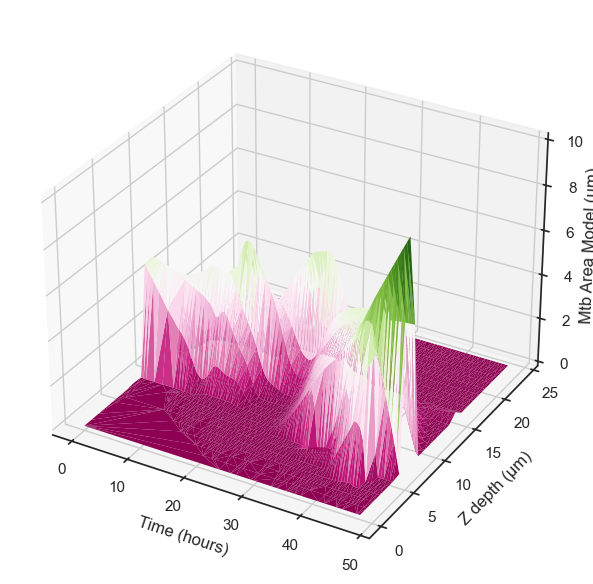

In [526]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots
import numpy as np
# subset & coerce to numeric
df_sub = df.loc[df["ID_og"] == 2280, ["Time (hours)", "Mtb Area Model (µm)", "z"]].copy()
for c in ["Time (hours)", "Mtb Area Model (µm)", "z"]:
    df_sub[c] = pd.to_numeric(df_sub[c], errors="coerce")
df_sub = df_sub.dropna()

# numpy arrays (float)
x = df_sub["Time (hours)"].to_numpy(dtype=float)
z = df_sub["Mtb Area Model (µm)"].to_numpy(dtype=float)
y = df_sub["z"].to_numpy(dtype=float)

# 3D surface from irregular points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(6, 6), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_trisurf(x, y, z, cmap="PiYG", edgecolor="none")

ax.set_xlabel("Time (hours)", labelpad=5)
ax.set_zlabel("Mtb Area Model (µm)", labelpad=0)
ax.set_ylabel("Z depth (µm)", labelpad=5,)
plt.subplots_adjust(left=0.15, right=1, top=-0.95, bottom=0.1)

# fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, label="Z depth (µm)")
plt.tight_layout()
plt.show()


In [500]:
z_data

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,0,27.809850,49.619360,83.080670,116.66320,130.41400,150.72060,220.18710,156.15360,148.64160,...,49.961420,21.89279,17.025520,11.743170,14.752260,13.667100,5.677561,3.312340,1.156517,-0.147662
1,1,27.719660,48.550220,65.213740,95.27666,116.99640,133.90560,152.34120,151.93400,160.11390,...,33.088710,38.40972,44.248430,69.578600,4.019351,3.050024,3.039719,2.996142,2.967954,1.999594
2,2,30.426700,33.477520,44.809530,62.47495,77.43523,104.21530,102.73930,137.00040,186.07060,...,48.471320,74.71461,60.090900,7.073525,6.089851,6.537450,6.666096,7.306965,5.736840,3.625628
3,3,16.665490,30.108600,39.969520,44.12225,59.57512,77.56929,106.89250,166.55390,175.23810,...,60.559160,55.92124,15.172840,8.248324,36.680870,61.934130,20.268670,68.588190,46.498120,0.236010
4,4,8.815617,18.351600,8.658275,27.58590,48.62691,60.18013,91.32860,145.71090,116.06530,...,47.426910,69.20731,44.954680,29.171970,17.916740,16.255150,14.655590,17.260480,31.222450,46.717040
5,5,6.628881,10.413390,24.819390,26.08952,30.16050,52.30802,64.71007,76.30823,84.63686,...,140.264700,81.26501,56.457560,30.421640,17.287820,8.302431,2.981626,2.698536,5.886086,5.268358
6,6,21.839750,6.639270,18.970850,32.89204,43.15014,62.86014,104.66570,130.22940,114.84940,...,122.422100,123.96980,109.095200,98.419560,77.613740,32.490310,14.673440,7.370775,0.037110,0.642339
7,7,53.343030,26.797970,6.639270,10.88787,17.20440,56.18116,79.70141,90.84530,98.27675,...,68.174900,46.24076,39.938570,31.216530,36.883350,40.025250,117.429700,12.703280,1.729771,0.000000
8,8,25.667850,63.057170,22.141400,17.07400,41.74483,60.27227,81.42432,114.44400,102.32340,...,59.193550,42.47175,14.635980,6.944074,6.944075,27.749360,0.000000,0.000000,0.094494,0.077323
9,9,12.827000,69.205540,46.762930,13.96517,33.88744,61.82613,84.74799,121.12200,145.27410,...,79.344250,25.93483,6.944074,6.944074,6.944075,7.553681,0.000000,0.000000,0.000000,0.000000


# to-do: 

1. Inspect individual sc graphs
2. Make animations